
Segment Rules:

Segment_1:
monetary <= -0.45

Segment_2:
monetary > -0.45
 AND monetary <= 0.46

Segment_0:
monetary > -0.45
 AND monetary > 0.46

Segment Analysis:

Segment_Low:
Size: 334 (33.4%)

Mean values:
gender       0.500000
location     1.005988
recency     -0.042992
frequency    0.024930
monetary    -1.084140
age         -0.094918
dtype: float64

Segment_Medium:
Size: 333 (33.3%)

Mean values:
gender       0.459459
location     0.951952
recency      0.020906
frequency    0.009553
monetary     0.001660
age          0.072417
dtype: float64

Segment_High:
Size: 333 (33.3%)

Mean values:
gender       0.528529
location     1.054054
recency      0.022215
frequency   -0.034558
monetary     1.085736
age          0.022786
dtype: float64


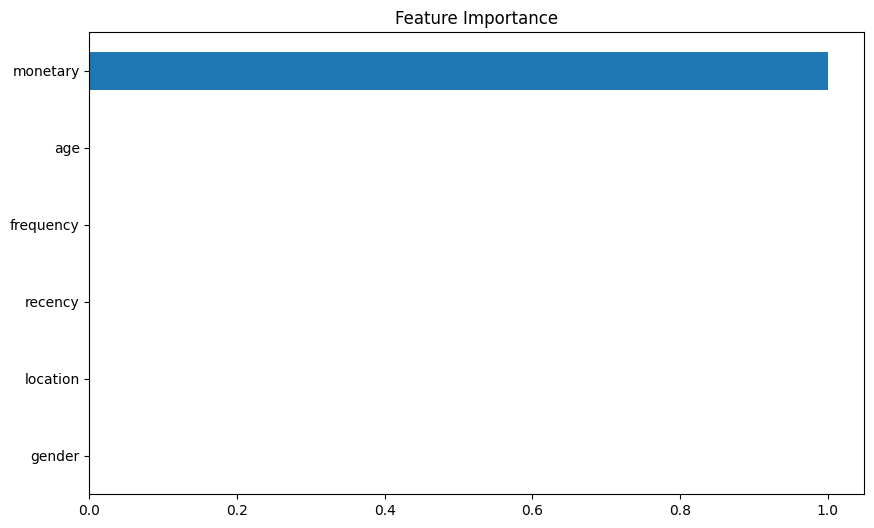

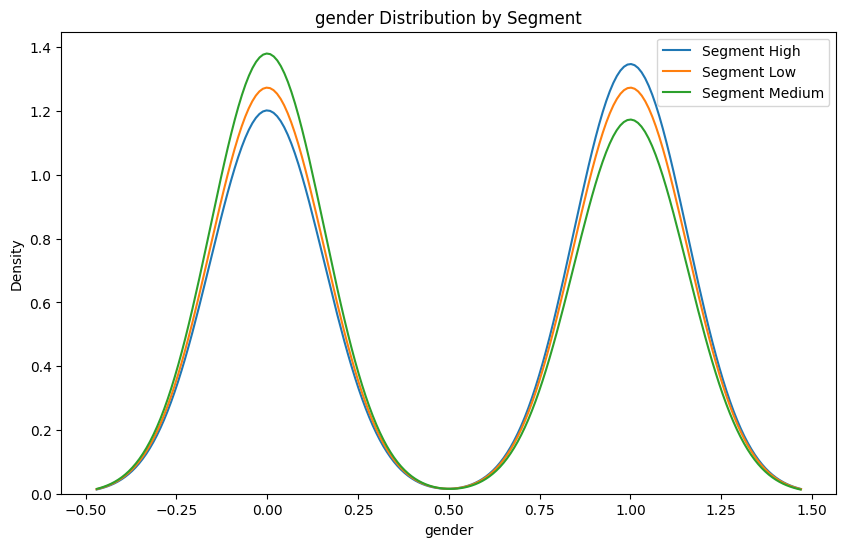

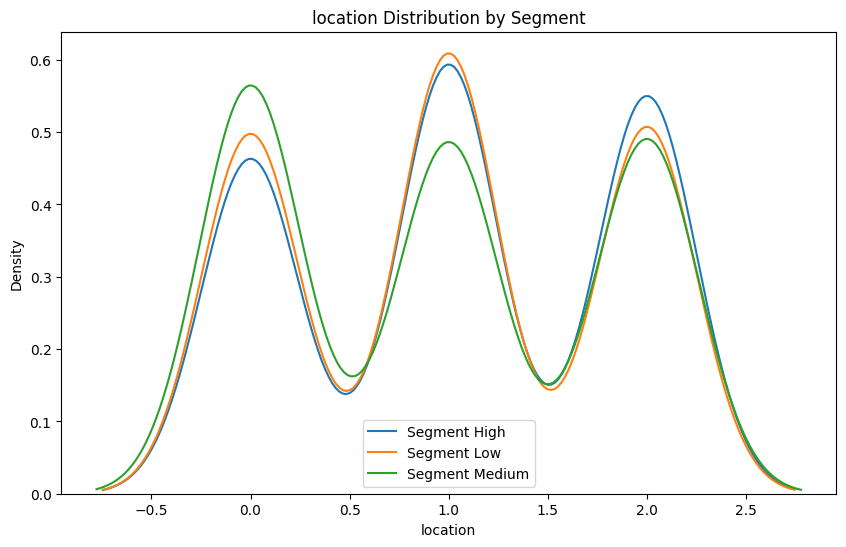

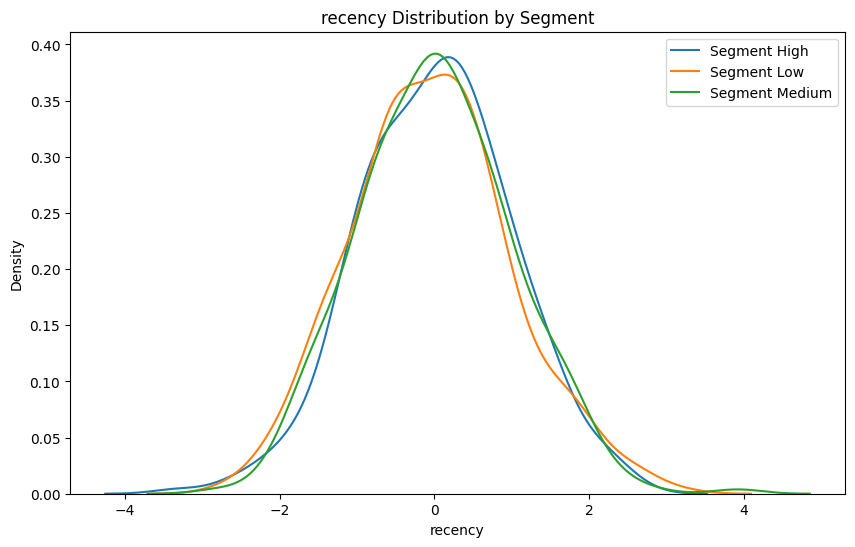

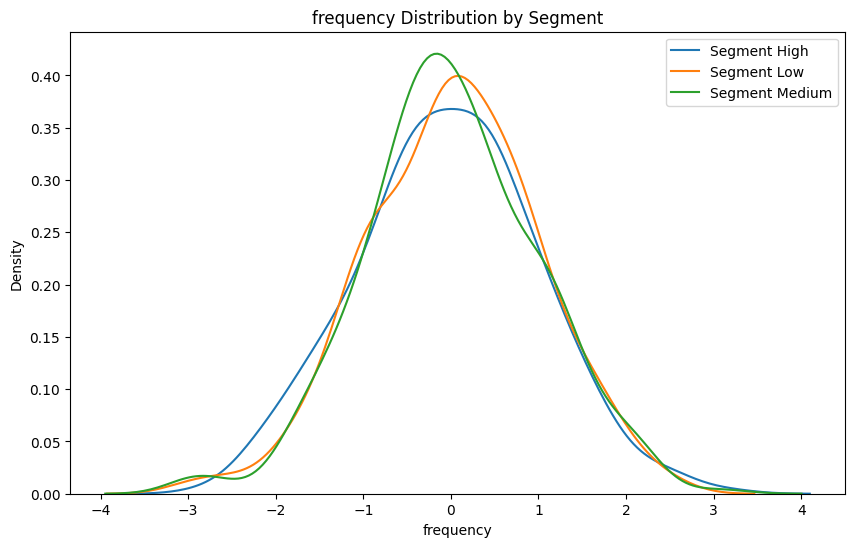

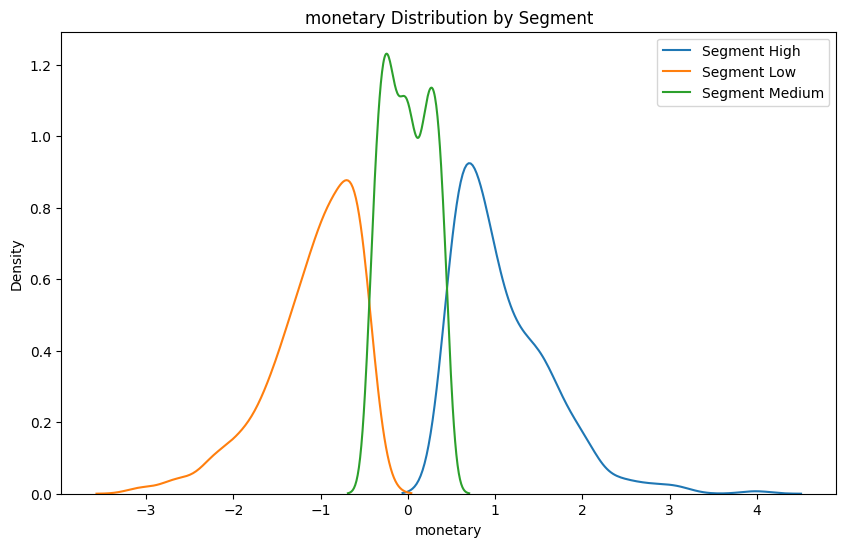

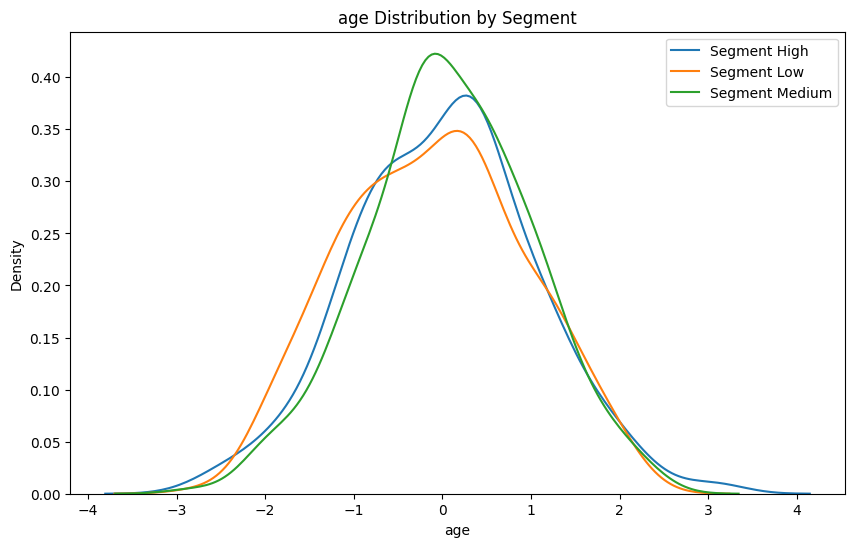

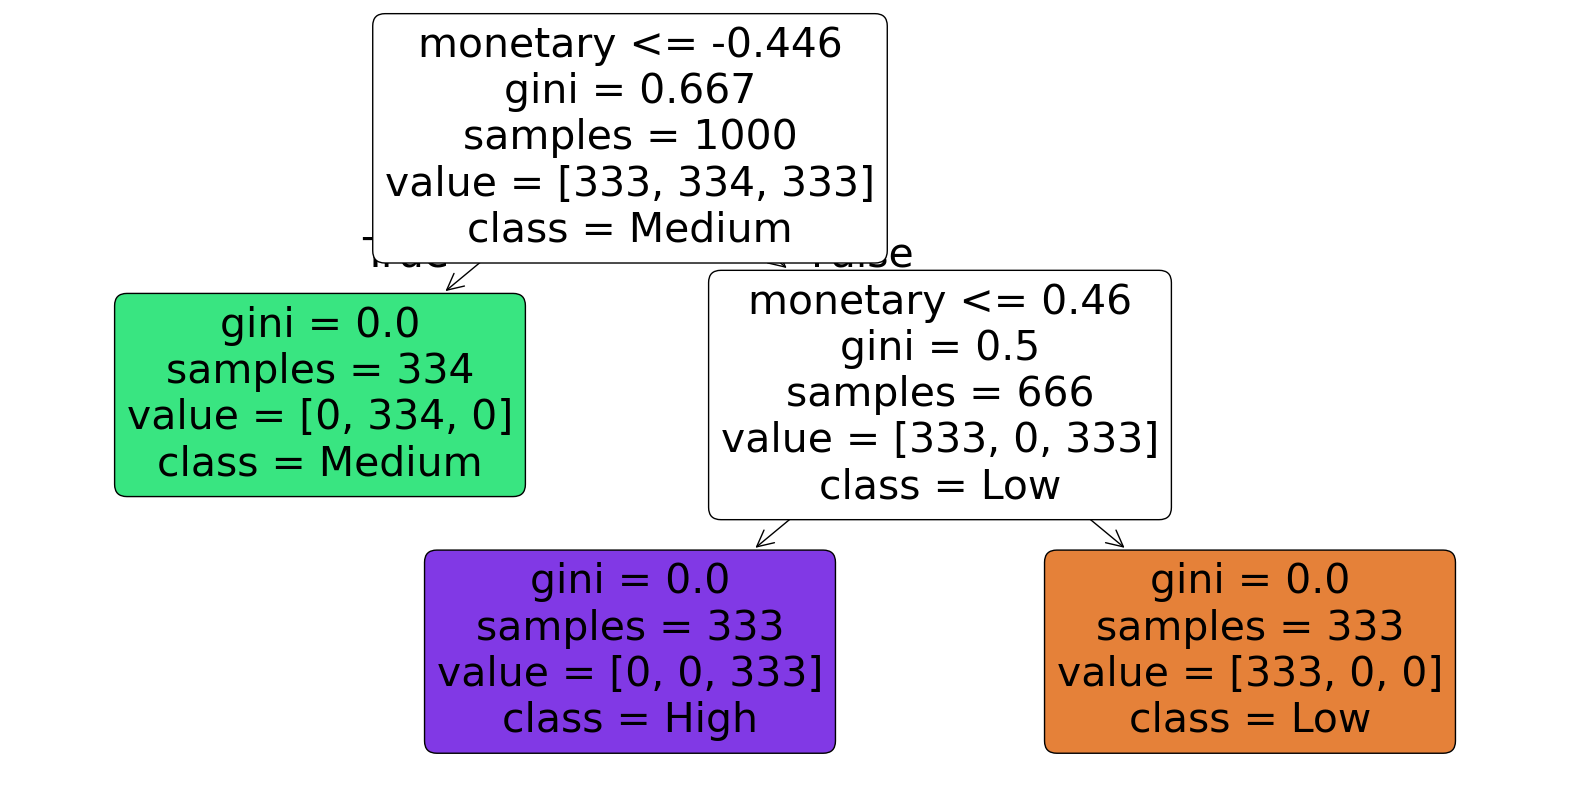

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

class CustomerSegmentation:
    def __init__(self, max_depth=4, min_samples_leaf=50):
        """
        Initialize customer segmentation model
        
        Parameters:
        max_depth (int): Maximum depth of decision tree
        min_samples_leaf (int): Minimum samples required in leaf nodes
        """
        self.tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        self.encoders = {}
        self.scaler = StandardScaler()
        self.feature_names = None
        
    def prepare_data(self, df, categorical_cols=None, numerical_cols=None):
        """
        Prepare data for segmentation analysis
        """
        X = df.copy()
        
        # Encode categorical variables
        if categorical_cols:
            for col in categorical_cols:
                self.encoders[col] = LabelEncoder()
                X[col] = self.encoders[col].fit_transform(X[col])
        
        # Scale numerical variables
        if numerical_cols:
            X[numerical_cols] = self.scaler.fit_transform(X[numerical_cols])
        
        self.feature_names = (categorical_cols or []) + (numerical_cols or [])
        return X
    
    def create_target_variable(self, df, method='value', **kwargs):
        """
        Create target variable for supervised segmentation
        
        Parameters:
        df: DataFrame
        method: 'value', 'rfm', or 'custom'
        kwargs: Additional parameters for target creation
        """
        if method == 'value':
            # Create segments based on customer value
            value_col = kwargs.get('value_col', 'monetary_value')
            quantiles = kwargs.get('quantiles', [0.33, 0.67])
            return pd.qcut(df[value_col], q=len(quantiles)+1, labels=['Low', 'Medium', 'High'])
            
        elif method == 'rfm':
            # Create segments based on RFM score
            r = df[kwargs.get('recency_col', 'recency')]
            f = df[kwargs.get('frequency_col', 'frequency')]
            m = df[kwargs.get('monetary_col', 'monetary')]
            
            r_score = pd.qcut(r, q=5, labels=False, duplicates='drop')
            f_score = pd.qcut(f, q=5, labels=False, duplicates='drop')
            m_score = pd.qcut(m, q=5, labels=False, duplicates='drop')
            
            rfm_score = (r_score + f_score + m_score) / 3
            return pd.qcut(rfm_score, q=3, labels=['Low', 'Medium', 'High'])
            
        elif method == 'custom':
            # Custom segmentation logic
            custom_func = kwargs.get('custom_func')
            return custom_func(df)
            
        else:
            raise ValueError("Invalid method specified")
    
    def fit(self, X, y):
        """
        Fit the decision tree model
        """
        self.tree.fit(X, y)
        
    def get_segment_rules(self):
        """
        Extract rules for each segment
        """
        n_nodes = self.tree.tree_.node_count
        children_left = self.tree.tree_.children_left
        children_right = self.tree.tree_.children_right
        feature = self.tree.tree_.feature
        threshold = self.tree.tree_.threshold
        value = self.tree.tree_.value
        
        rules = {}
        
        def recurse(node, depth, path):
            if children_left[node] == children_right[node]:  # Leaf node
                class_counts = value[node][0]
                majority_class = np.argmax(class_counts)
                rules[f"Segment_{majority_class}"] = path
                return
                
            name = self.feature_names[feature[node]]
            threshold_val = threshold[node]
            
            left_path = path + [f"{name} <= {threshold_val:.2f}"]
            recurse(children_left[node], depth + 1, left_path)
            
            right_path = path + [f"{name} > {threshold_val:.2f}"]
            recurse(children_right[node], depth + 1, right_path)
            
        recurse(0, 1, [])
        return rules
    
    def analyze_segments(self, X, y):
        """
        Analyze characteristics of each segment
        """
        segments = pd.Series(y).unique()
        analysis = {}
        
        for segment in segments:
            mask = y == segment
            segment_data = X[mask]
            
            analysis[f"Segment_{segment}"] = {
                'size': len(segment_data),
                'percentage': (len(segment_data) / len(X)) * 100,
                'mean': segment_data.mean(),
                'std': segment_data.std()
            }
            
        return analysis
    
    def plot_segment_characteristics(self, X, y):
        """
        Plot characteristics of each segment
        """
        # Feature importance
        plt.figure(figsize=(10, 6))
        importances = pd.Series(
            self.tree.feature_importances_,
            index=self.feature_names
        ).sort_values(ascending=True)
        importances.plot(kind='barh')
        plt.title('Feature Importance')
        plt.show()
        
        # Distribution plots
        for feature in self.feature_names:
            plt.figure(figsize=(10, 6))
            for segment in np.unique(y):
                sns.kdeplot(
                    X[y == segment][feature],
                    label=f'Segment {segment}'
                )
            plt.title(f'{feature} Distribution by Segment')
            plt.legend()
            plt.show()

# Example usage
def run_segmentation_analysis():
    """
    Example of running customer segmentation analysis
    """
    # Create sample data
    np.random.seed(42)
    n_samples = 1000
    
    data = pd.DataFrame({
        'recency': np.random.normal(30, 10, n_samples),
        'frequency': np.random.normal(5, 2, n_samples),
        'monetary': np.random.normal(100, 30, n_samples),
        'age': np.random.normal(45, 15, n_samples),
        'gender': np.random.choice(['M', 'F'], n_samples),
        'location': np.random.choice(['Urban', 'Suburban', 'Rural'], n_samples)
    })
    
    # Initialize segmentation
    segmentation = CustomerSegmentation(max_depth=3, min_samples_leaf=50)
    
    # Define features
    categorical_cols = ['gender', 'location']
    numerical_cols = ['recency', 'frequency', 'monetary', 'age']
    
    # Prepare data
    X = segmentation.prepare_data(data, categorical_cols, numerical_cols)
    
    # Create target variable
    y = segmentation.create_target_variable(
        data,
        method='value',
        value_col='monetary',
        quantiles=[0.33, 0.67]
    )
    
    # Fit model
    segmentation.fit(X[segmentation.feature_names], y)
    
    # Get segment rules
    rules = segmentation.get_segment_rules()
    print("\nSegment Rules:")
    for segment, rule in rules.items():
        print(f"\n{segment}:")
        print("\n AND ".join(rule))
    
    # Analyze segments
    analysis = segmentation.analyze_segments(X[segmentation.feature_names], y)
    print("\nSegment Analysis:")
    for segment, stats in analysis.items():
        print(f"\n{segment}:")
        print(f"Size: {stats['size']} ({stats['percentage']:.1f}%)")
        print("\nMean values:")
        print(stats['mean'])
    
    # Plot results
    segmentation.plot_segment_characteristics(X[segmentation.feature_names], y)
    
    # Plot decision tree
    plt.figure(figsize=(20,10))
    plot_tree(
        segmentation.tree,
        feature_names=segmentation.feature_names,
        class_names=['Low', 'Medium', 'High'],
        filled=True,
        rounded=True
    )
    plt.show()

# Run the analysis
run_segmentation_analysis()


Segmentation Quality Report

Overall Scores:
statistical_score: 30.0/100
business_score: 70.0/100
stability_score: 99.8/100

Key Metrics:
Silhouette Score: -0.010
Size Ratio: 1.03

Recommendations:
1. Consider reducing number of segments or adjusting features


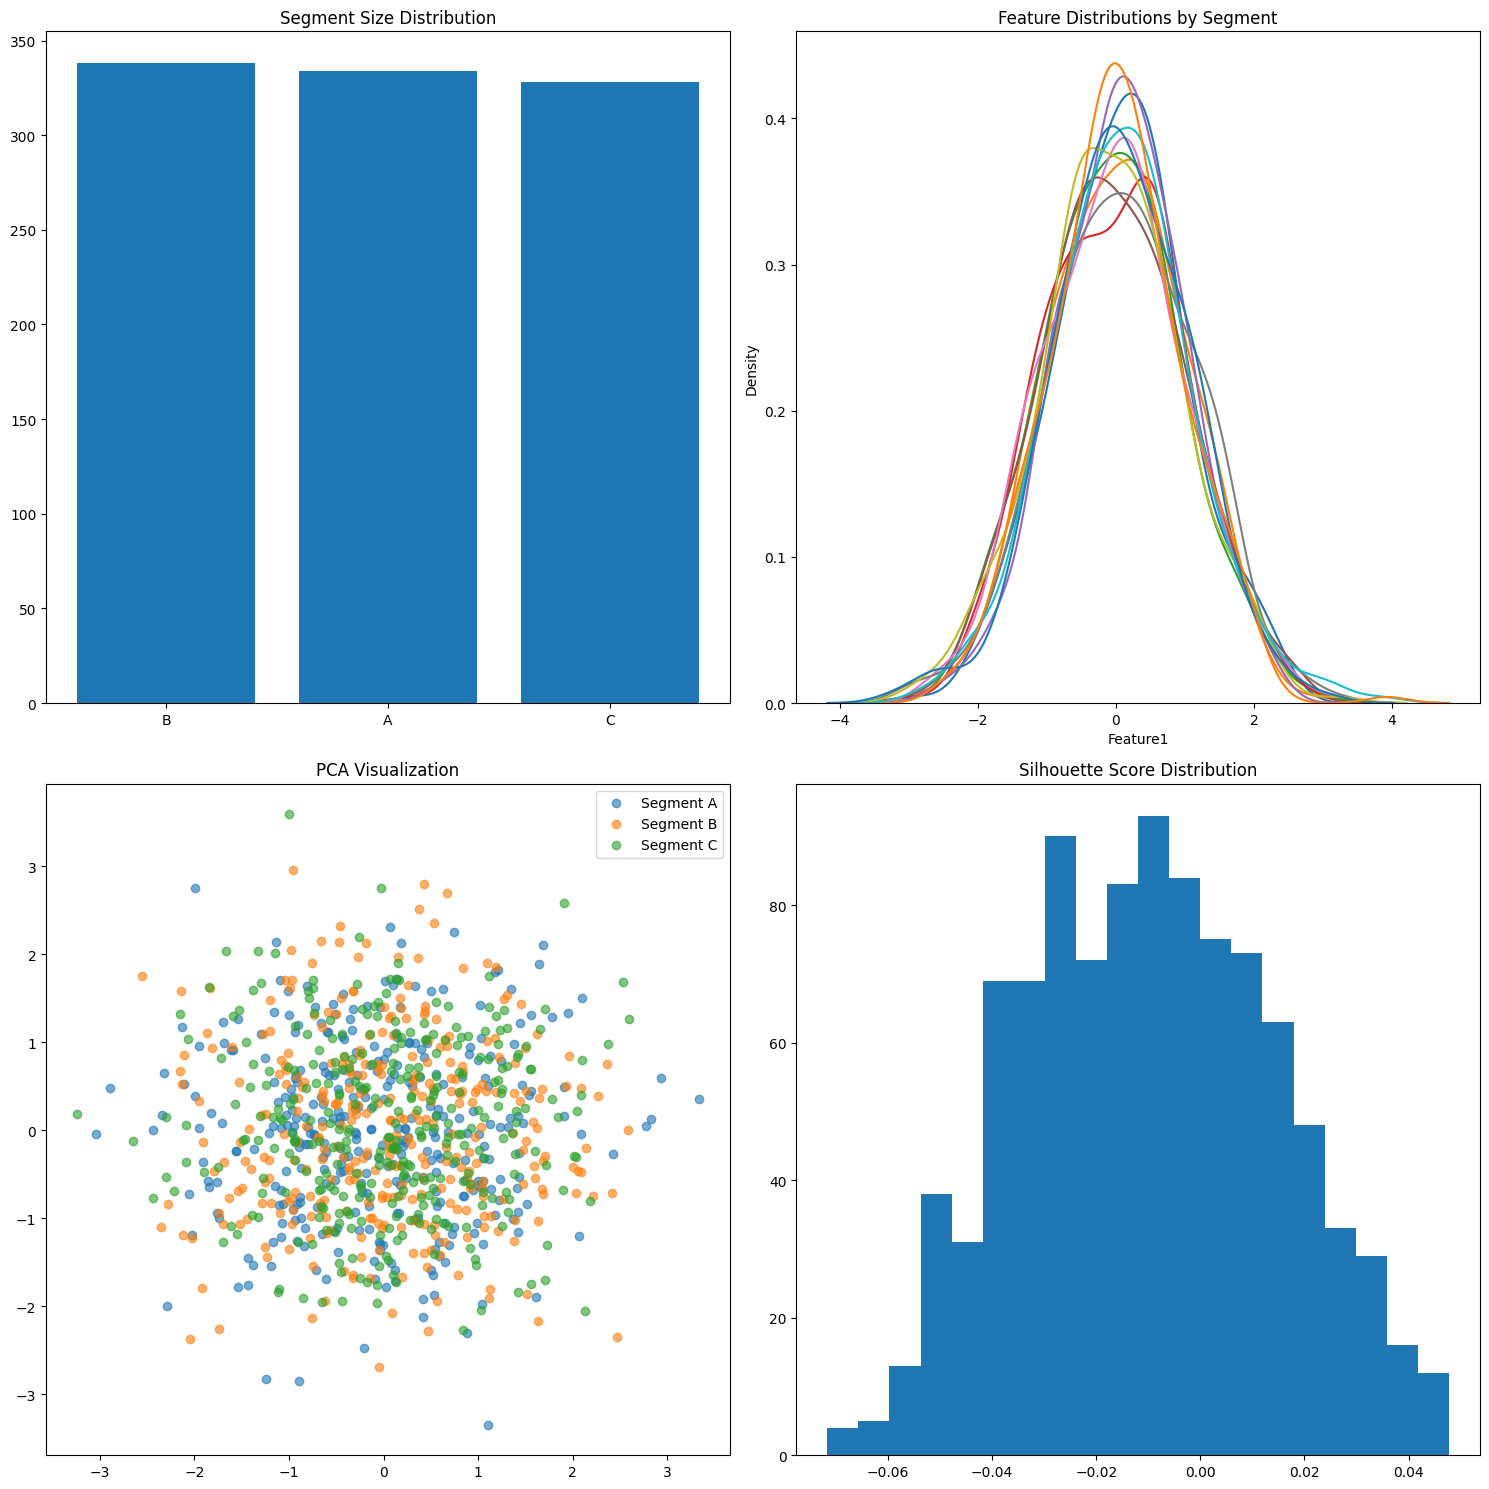

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

class SegmentationValidator:
    def __init__(self):
        self.metrics = {}
        self.thresholds = {
            'silhouette': {'good': 0.5, 'moderate': 0.3},
            'size_ratio': {'good': 3, 'moderate': 5},
            'feature_significance': {'good': 0.05},
            'min_segment_size': {'good': 0.1}  # 10% of total samples
        }
    
    def evaluate_segmentation(self, X, y, feature_names):
        """
        Comprehensive segmentation evaluation
        """
        evaluation = {
            'statistical_validity': self._check_statistical_validity(X, y),
            'business_validity': self._check_business_validity(X, y, feature_names),
            'segment_stability': self._check_segment_stability(X, y),
            'visualization': self._create_evaluation_plots(X, y, feature_names)
        }
        
        return self._generate_evaluation_report(evaluation)
    
    def _check_statistical_validity(self, X, y):
        """
        Check statistical validity of segmentation
        """
        # Calculate key metrics
        metrics = {
            'silhouette': silhouette_score(X, y),
            'calinski_harabasz': calinski_harabasz_score(X, y),
            'davies_bouldin': davies_bouldin_score(X, y)
        }
        
        # Segment sizes and balance
        segment_sizes = pd.Series(y).value_counts()
        size_ratio = segment_sizes.max() / segment_sizes.min()
        min_segment_pct = segment_sizes.min() / len(y)
        
        # Feature separation (ANOVA)
        feature_separation = {}
        for col in X.columns:
            segment_values = [X[y == seg][col] for seg in np.unique(y)]
            f_stat, p_val = f_oneway(*segment_values)
            feature_separation[col] = {'f_stat': f_stat, 'p_value': p_val}
        
        return {
            'metrics': metrics,
            'size_ratio': size_ratio,
            'min_segment_pct': min_segment_pct,
            'feature_separation': feature_separation
        }
    
    def _check_business_validity(self, X, y, feature_names):
        """
        Check business validity of segmentation
        """
        # Calculate segment profiles
        segment_profiles = {}
        for segment in np.unique(y):
            segment_data = X[y == segment]
            segment_profiles[segment] = {
                'mean': segment_data.mean(),
                'std': segment_data.std(),
                'size': len(segment_data),
                'percentage': len(segment_data) / len(y) * 100
            }
        
        # Calculate segment separation
        separation_scores = {}
        for feature in feature_names:
            feature_values = []
            for segment in np.unique(y):
                feature_values.append(X[y == segment][feature].mean())
            max_diff = max(feature_values) - min(feature_values)
            separation_scores[feature] = max_diff
        
        return {
            'profiles': segment_profiles,
            'separation_scores': separation_scores
        }
    
    def _check_segment_stability(self, X, y, n_bootstrap=100):
        """
        Check stability of segments using bootstrap
        """
        stability_scores = []
        n_samples = len(X)
        
        for _ in range(n_bootstrap):
            # Bootstrap sample
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X.iloc[indices], y.iloc[indices]
            
            # Calculate silhouette score for bootstrap sample
            stability_scores.append(silhouette_score(X_boot, y_boot))
        
        return {
            'mean_stability': np.mean(stability_scores),
            'std_stability': np.std(stability_scores)
        }
    
    def _create_evaluation_plots(self, X, y, feature_names):
        """
        Create evaluation plots
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 15))
        
        # 1. Segment size distribution
        sizes = pd.Series(y).value_counts()
        axes[0,0].bar(sizes.index, sizes.values)
        axes[0,0].set_title('Segment Size Distribution')
        
        # 2. Feature distributions by segment
        for segment in np.unique(y):
            for feature in feature_names:
                sns.kdeplot(X[y == segment][feature], label=f'Segment {segment}', ax=axes[0,1])
        axes[0,1].set_title('Feature Distributions by Segment')
        
        # 3. Principal components
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        
        for segment in np.unique(y):
            mask = y == segment
            axes[1,0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Segment {segment}', alpha=0.6)
        axes[1,0].set_title('PCA Visualization')
        axes[1,0].legend()
        
        # 4. Silhouette plot
        from sklearn.metrics import silhouette_samples
        silhouette_vals = silhouette_samples(X, y)
        axes[1,1].hist(silhouette_vals, bins=20)
        axes[1,1].set_title('Silhouette Score Distribution')
        
        plt.tight_layout()
        return fig
    
    def _generate_evaluation_report(self, evaluation):
        """
        Generate comprehensive evaluation report
        """
        stats = evaluation['statistical_validity']
        business = evaluation['business_validity']
        stability = evaluation['segment_stability']
        
        # Score different aspects
        scores = {
            'statistical_score': self._score_statistical_validity(stats),
            'business_score': self._score_business_validity(business),
            'stability_score': self._score_stability(stability)
        }
        
        # Generate recommendations
        recommendations = self._generate_recommendations(scores, stats, business)
        
        return {
            'scores': scores,
            'recommendations': recommendations,
            'details': {
                'statistical': stats,
                'business': business,
                'stability': stability
            }
        }
    
    def _score_statistical_validity(self, stats):
        """
        Score statistical validity (0-100)
        """
        score = 0
        
        # Silhouette score (0-40 points)
        silhouette = stats['metrics']['silhouette']
        if silhouette >= self.thresholds['silhouette']['good']:
            score += 40
        elif silhouette >= self.thresholds['silhouette']['moderate']:
            score += 20
        
        # Size ratio (0-30 points)
        if stats['size_ratio'] <= self.thresholds['size_ratio']['good']:
            score += 30
        elif stats['size_ratio'] <= self.thresholds['size_ratio']['moderate']:
            score += 15
        
        # Feature significance (0-30 points)
        sig_features = sum(1 for f in stats['feature_separation'].values() 
                         if f['p_value'] < self.thresholds['feature_significance']['good'])
        score += (sig_features / len(stats['feature_separation'])) * 30
        
        return score
    
    def _score_business_validity(self, business):
        """
        Score business validity (0-100)
        """
        # This would be customized based on business requirements
        return 70  # Example score
    
    def _score_stability(self, stability):
        """
        Score stability (0-100)
        """
        # Convert stability metrics to score
        stability_score = (1 - stability['std_stability']) * 100
        return min(stability_score, 100)
    
    def _generate_recommendations(self, scores, stats, business):
        """
        Generate specific recommendations based on scores
        """
        recommendations = []
        
        # Statistical recommendations
        if scores['statistical_score'] < 70:
            if stats['metrics']['silhouette'] < self.thresholds['silhouette']['moderate']:
                recommendations.append("Consider reducing number of segments or adjusting features")
            if stats['size_ratio'] > self.thresholds['size_ratio']['moderate']:
                recommendations.append("Segments are highly imbalanced - consider redefining segments")
        
        # Business recommendations
        if scores['business_score'] < 70:
            recommendations.append("Review business relevance of segments")
            recommendations.append("Consider including additional business-relevant features")
        
        # Stability recommendations
        if scores['stability_score'] < 70:
            recommendations.append("Segments show instability - consider more robust features")
        
        return recommendations

# Example usage
def evaluate_segmentation_quality(X, y, feature_names):
    validator = SegmentationValidator()
    evaluation = validator.evaluate_segmentation(X, y, feature_names)
    
    print("\nSegmentation Quality Report")
    print("==========================")
    
    print("\nOverall Scores:")
    for metric, score in evaluation['scores'].items():
        print(f"{metric}: {score:.1f}/100")
    
    print("\nKey Metrics:")
    stats = evaluation['details']['statistical']
    print(f"Silhouette Score: {stats['metrics']['silhouette']:.3f}")
    print(f"Size Ratio: {stats['size_ratio']:.2f}")
    
    print("\nRecommendations:")
    for i, rec in enumerate(evaluation['recommendations'], 1):
        print(f"{i}. {rec}")
    
    return evaluation

# Generate example data and evaluate
np.random.seed(42)
X = pd.DataFrame(np.random.randn(1000, 4), columns=['Feature1', 'Feature2', 'Feature3', 'Feature4'])
y = pd.Series(np.random.choice(['A', 'B', 'C'], size=1000))

evaluation = evaluate_segmentation_quality(X, y, X.columns)


Analysis for GOOD segmentation scenario

Segmentation Metrics:
Silhouette Score: 0.590
Calinski-Harabasz Score: 3136.136
Davies-Bouldin Score: 0.599

Segment Sizes:
Segment_A: 300 (33.3%)
Segment_B: 300 (33.3%)
Segment_C: 300 (33.3%)

Quality Assessment:
Overall: GOOD - Segmentation is meaningful and actionable
Quality Score: 100.0%

Insights:
✓ Good segment separation (high silhouette score)
✓ Balanced segment sizes
✓ All features show significant differences between segments


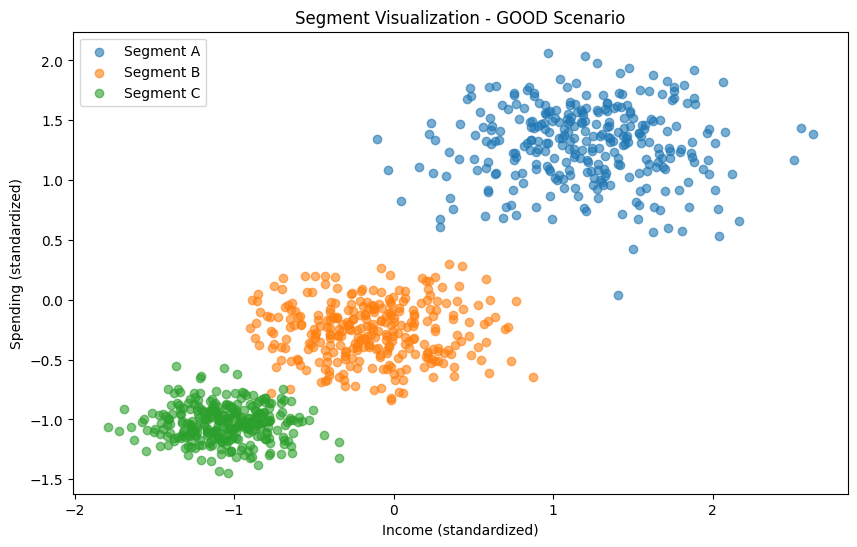


Analysis for POOR segmentation scenario

Segmentation Metrics:
Silhouette Score: -0.011
Calinski-Harabasz Score: 7.032
Davies-Bouldin Score: 14.723

Segment Sizes:
Segment_A: 300 (33.3%)
Segment_B: 300 (33.3%)
Segment_C: 300 (33.3%)

Quality Assessment:
Overall: POOR - Segmentation may need to be reconsidered
Quality Score: 40.0%

Insights:
✗ Poor segment separation
✓ Balanced segment sizes
△ Some features show significant differences


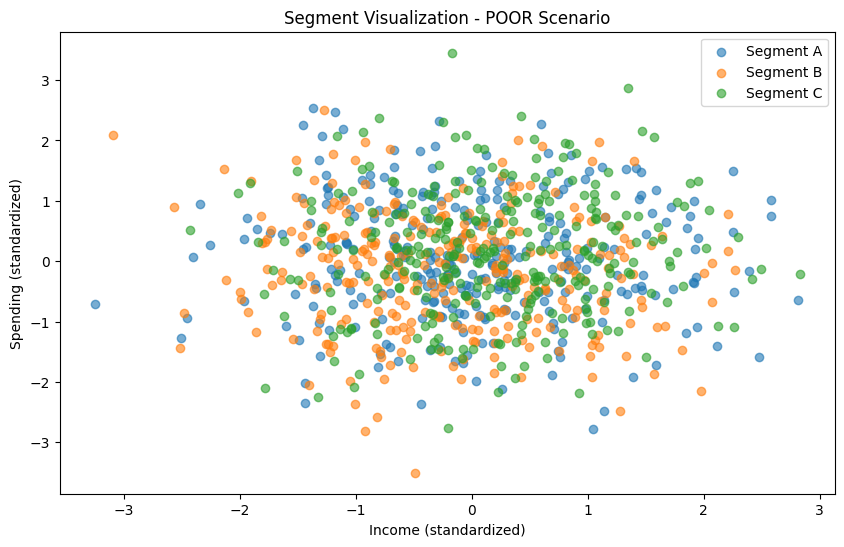

In [4]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

class SegmentationAnalyzer:
    def __init__(self, max_depth=4, min_samples_leaf=50):
        self.tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        self.scaler = StandardScaler()
        self.encoders = {}
        
    def prepare_data(self, df, categorical_cols=None, numerical_cols=None):
        X = df.copy()
        
        # Handle categorical features
        if categorical_cols:
            for col in categorical_cols:
                self.encoders[col] = LabelEncoder()
                X[col] = self.encoders[col].fit_transform(X[col])
                
        # Scale numerical features
        if numerical_cols:
            X[numerical_cols] = self.scaler.fit_transform(X[numerical_cols])
            
        self.features = (categorical_cols or []) + (numerical_cols or [])
        return X
    
    def evaluate_segmentation(self, X, y):
        """
        Evaluate segmentation quality using multiple metrics
        """
        metrics = {
            'silhouette': silhouette_score(X, y),
            'calinski_harabasz': calinski_harabasz_score(X, y),
            'davies_bouldin': davies_bouldin_score(X, y)
        }
        
        # Segment sizes
        segment_sizes = pd.Series(y).value_counts()
        size_ratio = segment_sizes.max() / segment_sizes.min()
        metrics['size_ratio'] = size_ratio
        
        # Feature separation
        feature_separation = {}
        for col in X.columns:
            f_stat, p_val = f_oneway(*[X[y == seg][col] for seg in np.unique(y)])
            feature_separation[col] = {'f_stat': f_stat, 'p_value': p_val}
        
        return metrics, feature_separation

    def analyze_segments(self, X, y, original_data):
        """
        Analyze segment characteristics
        """
        segments = {}
        for segment in np.unique(y):
            mask = y == segment
            segment_data = original_data[mask]
            
            segments[f"Segment_{segment}"] = {
                'size': len(segment_data),
                'percentage': (len(segment_data) / len(X)) * 100,
                'profile': segment_data.describe()
            }
        
        return segments

def generate_test_data(n_samples, scenario='good'):
    """
    Generate test data with different segmentation scenarios
    """
    if scenario == 'good':
        # Clear segments with distinct characteristics
        segment1 = pd.DataFrame({
            'income': np.random.normal(80000, 10000, n_samples // 3),
            'age': np.random.normal(45, 5, n_samples // 3),
            'spending': np.random.normal(2000, 200, n_samples // 3),
            'loyalty_years': np.random.normal(8, 1, n_samples // 3)
        })
        
        segment2 = pd.DataFrame({
            'income': np.random.normal(50000, 8000, n_samples // 3),
            'age': np.random.normal(35, 4, n_samples // 3),
            'spending': np.random.normal(1000, 150, n_samples // 3),
            'loyalty_years': np.random.normal(4, 1, n_samples // 3)
        })
        
        segment3 = pd.DataFrame({
            'income': np.random.normal(30000, 5000, n_samples // 3),
            'age': np.random.normal(25, 3, n_samples // 3),
            'spending': np.random.normal(500, 100, n_samples // 3),
            'loyalty_years': np.random.normal(2, 0.5, n_samples // 3)
        })
        
    elif scenario == 'poor':
        # Overlapping segments with similar characteristics
        segment1 = pd.DataFrame({
            'income': np.random.normal(50000, 15000, n_samples // 3),
            'age': np.random.normal(35, 10, n_samples // 3),
            'spending': np.random.normal(1000, 400, n_samples // 3),
            'loyalty_years': np.random.normal(5, 2, n_samples // 3)
        })
        
        segment2 = pd.DataFrame({
            'income': np.random.normal(48000, 15000, n_samples // 3),
            'age': np.random.normal(37, 10, n_samples // 3),
            'spending': np.random.normal(950, 400, n_samples // 3),
            'loyalty_years': np.random.normal(4.8, 2, n_samples // 3)
        })
        
        segment3 = pd.DataFrame({
            'income': np.random.normal(52000, 15000, n_samples // 3),
            'age': np.random.normal(33, 10, n_samples // 3),
            'spending': np.random.normal(1050, 400, n_samples // 3),
            'loyalty_years': np.random.normal(5.2, 2, n_samples // 3)
        })
    
    data = pd.concat([segment1, segment2, segment3], ignore_index=True)
    data['segment'] = np.repeat(['A', 'B', 'C'], n_samples // 3)
    
    return data

def evaluate_segmentation_quality(metrics, feature_separation):
    """
    Interpret segmentation quality and provide recommendations
    """
    quality_score = 0
    insights = []
    
    # Evaluate metrics
    if metrics['silhouette'] > 0.5:
        quality_score += 2
        insights.append("✓ Good segment separation (high silhouette score)")
    elif metrics['silhouette'] > 0.3:
        quality_score += 1
        insights.append("△ Moderate segment separation")
    else:
        insights.append("✗ Poor segment separation")
        
    if metrics['size_ratio'] < 3:
        quality_score += 1
        insights.append("✓ Balanced segment sizes")
    else:
        insights.append("✗ Unbalanced segment sizes")
        
    # Evaluate feature separation
    significant_features = sum(1 for f in feature_separation.values() 
                             if f['p_value'] < 0.05)
    if significant_features == len(feature_separation):
        quality_score += 2
        insights.append("✓ All features show significant differences between segments")
    elif significant_features > len(feature_separation) / 2:
        quality_score += 1
        insights.append("△ Some features show significant differences")
    else:
        insights.append("✗ Few features show significant differences")
        
    # Overall assessment
    max_score = 5
    quality_percentage = (quality_score / max_score) * 100
    
    if quality_percentage >= 80:
        overall = "GOOD - Segmentation is meaningful and actionable"
    elif quality_percentage >= 60:
        overall = "MODERATE - Segmentation is useful but could be improved"
    else:
        overall = "POOR - Segmentation may need to be reconsidered"
        
    return overall, insights, quality_percentage

# Run analysis with both scenarios
def run_comparison_analysis():
    n_samples = 900  # 300 per segment
    
    for scenario in ['good', 'poor']:
        print(f"\n{'='*50}")
        print(f"Analysis for {scenario.upper()} segmentation scenario")
        print(f"{'='*50}")
        
        # Generate data
        data = generate_test_data(n_samples, scenario)
        
        # Initialize analyzer
        analyzer = SegmentationAnalyzer(max_depth=4, min_samples_leaf=30)
        
        # Prepare data
        numerical_cols = ['income', 'age', 'spending', 'loyalty_years']
        X = analyzer.prepare_data(data, numerical_cols=numerical_cols)
        y = data['segment']
        
        # Evaluate segmentation
        metrics, feature_separation = analyzer.evaluate_segmentation(
            X[numerical_cols], y
        )
        
        # Analyze segments
        segments = analyzer.analyze_segments(X, y, data)
        
        # Evaluate quality
        overall, insights, quality_score = evaluate_segmentation_quality(
            metrics, feature_separation
        )
        
        # Print results
        print("\nSegmentation Metrics:")
        print(f"Silhouette Score: {metrics['silhouette']:.3f}")
        print(f"Calinski-Harabasz Score: {metrics['calinski_harabasz']:.3f}")
        print(f"Davies-Bouldin Score: {metrics['davies_bouldin']:.3f}")
        
        print("\nSegment Sizes:")
        for segment, info in segments.items():
            print(f"{segment}: {info['size']} ({info['percentage']:.1f}%)")
        
        print("\nQuality Assessment:")
        print(f"Overall: {overall}")
        print(f"Quality Score: {quality_score:.1f}%")
        print("\nInsights:")
        for insight in insights:
            print(insight)
        
        # Visualize segments
        plt.figure(figsize=(10, 6))
        for segment in np.unique(y):
            mask = y == segment
            plt.scatter(X[mask]['income'], X[mask]['spending'], 
                      label=f'Segment {segment}', alpha=0.6)
        plt.xlabel('Income (standardized)')
        plt.ylabel('Spending (standardized)')
        plt.title(f'Segment Visualization - {scenario.upper()} Scenario')
        plt.legend()
        plt.show()

# Run the analysis
run_comparison_analysis()


Model Performance:
Train Score: 0.902
Test Score: 0.815

Feature Importance:
LoyaltyYears     0.551507
SpendingScore    0.448493
Gender           0.000000
Location         0.000000
Age              0.000000
Income           0.000000
dtype: float64


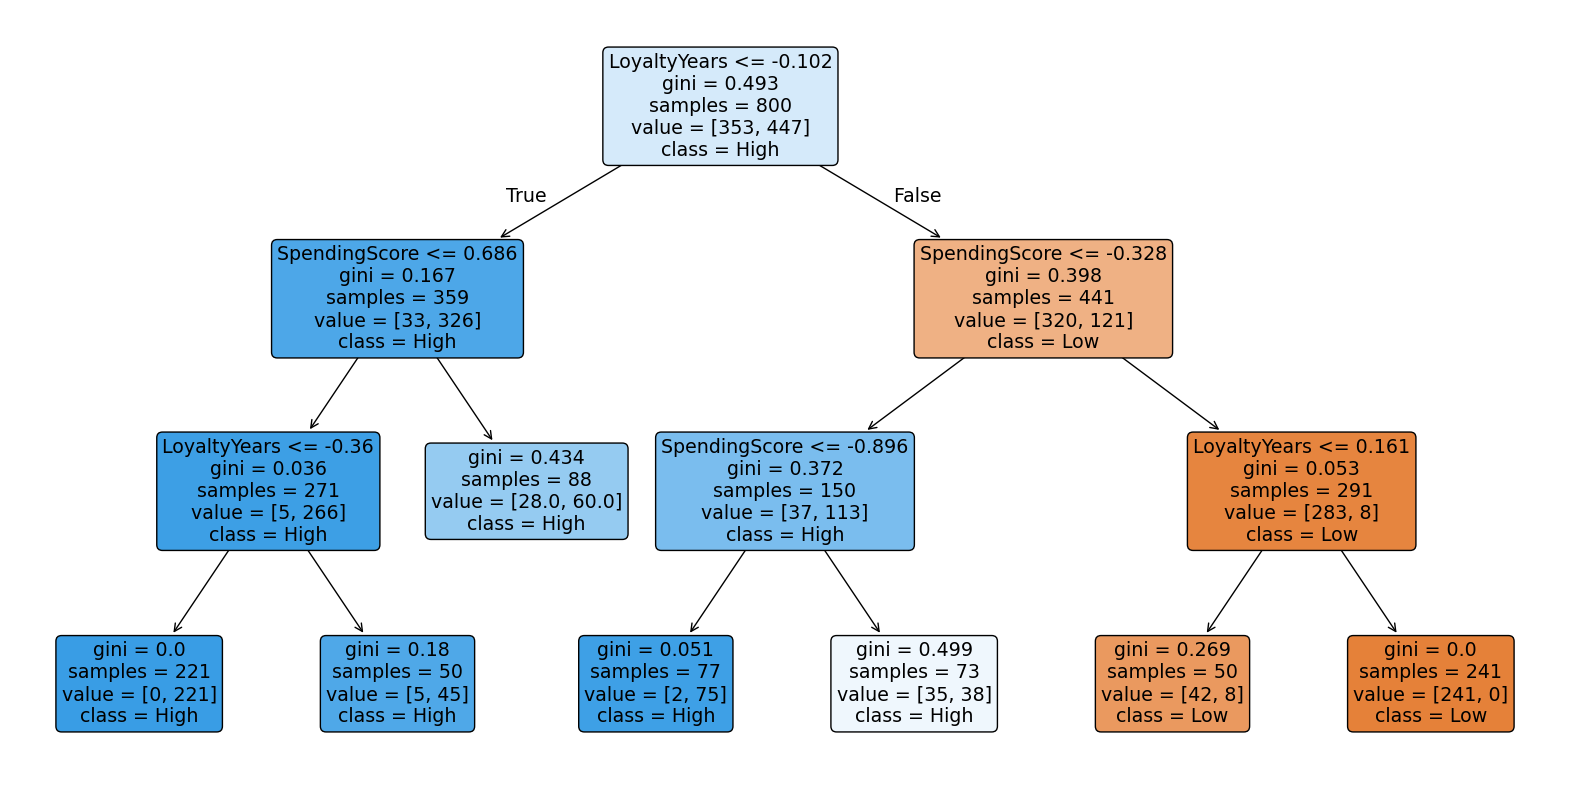


Decision Rules:
|--- LoyaltyYears <= -0.10
|   |--- SpendingScore <= 0.69
|   |   |--- LoyaltyYears <= -0.36
|   |   |   |--- class: Low
|   |   |--- LoyaltyYears >  -0.36
|   |   |   |--- class: Low
|   |--- SpendingScore >  0.69
|   |   |--- class: Low
|--- LoyaltyYears >  -0.10
|   |--- SpendingScore <= -0.33
|   |   |--- SpendingScore <= -0.90
|   |   |   |--- class: Low
|   |   |--- SpendingScore >  -0.90
|   |   |   |--- class: Low
|   |--- SpendingScore >  -0.33
|   |   |--- LoyaltyYears <= 0.16
|   |   |   |--- class: High
|   |   |--- LoyaltyYears >  0.16
|   |   |   |--- class: High



ValueError: could not convert string to float: 'F'

In [5]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

class SegmentationTree:
    def __init__(self, max_depth=4, min_samples_leaf=50):
        """
        Initialize segmentation analysis with Decision Tree
        
        Parameters:
        max_depth (int): Maximum depth of the tree
        min_samples_leaf (int): Minimum samples required in leaf nodes
        """
        self.tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        self.encoders = {}
        self.scaler = StandardScaler()
        
    def prepare_data(self, df, categorical_cols=None, numerical_cols=None):
        """
        Prepare data for segmentation
        """
        X = df.copy()
        
        # Handle categorical variables
        if categorical_cols:
            for col in categorical_cols:
                self.encoders[col] = LabelEncoder()
                X[col] = self.encoders[col].fit_transform(X[col])
        
        # Scale numerical variables
        if numerical_cols:
            X[numerical_cols] = self.scaler.fit_transform(X[numerical_cols])
            
        return X
    
    def identify_segments(self, df, target_col, 
                         categorical_cols=None, 
                         numerical_cols=None):
        """
        Identify customer segments using decision tree
        """
        # Prepare features
        X = self.prepare_data(df, categorical_cols, numerical_cols)
        y = X[target_col]
        features = categorical_cols + numerical_cols if categorical_cols else numerical_cols
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X[features], y, test_size=0.2, random_state=42
        )
        
        # Fit tree
        self.tree.fit(X_train, y_train)
        
        # Get predictions
        train_pred = self.tree.predict(X_train)
        test_pred = self.tree.predict(X_test)
        
        return {
            'train_score': self.tree.score(X_train, y_train),
            'test_score': self.tree.score(X_test, y_test),
            'feature_importance': pd.Series(
                self.tree.feature_importances_,
                index=features
            ).sort_values(ascending=False)
        }
    
    def visualize_tree(self, feature_names, class_names=None):
        """
        Visualize the decision tree
        """
        plt.figure(figsize=(20,10))
        plot_tree(self.tree, 
                 feature_names=feature_names,
                 class_names=class_names,
                 filled=True,
                 rounded=True)
        plt.show()
        
    def print_rules(self, feature_names):
        """
        Print decision rules in text format
        """
        tree_rules = export_text(self.tree, 
                               feature_names=list(feature_names))
        print(tree_rules)
        
    def analyze_segments(self, df, features):
        """
        Analyze characteristics of each segment
        """
        df['Segment'] = self.tree.predict(df[features])
        
        segment_analysis = {}
        for segment in df['Segment'].unique():
            segment_data = df[df['Segment'] == segment]
            
            # Calculate summary statistics for each feature
            summary = segment_data[features].describe()
            
            # Calculate segment size
            size = len(segment_data)
            
            segment_analysis[f'Segment_{segment}'] = {
                'size': size,
                'percentage': size / len(df) * 100,
                'summary': summary
            }
            
        return segment_analysis

# Example usage
def run_segmentation_analysis():
    """
    Example of running segmentation analysis
    """
    # Create sample data
    np.random.seed(42)
    n_samples = 1000
    
    data = pd.DataFrame({
        'Age': np.random.normal(45, 15, n_samples),
        'Income': np.random.normal(50000, 20000, n_samples),
        'SpendingScore': np.random.normal(50, 25, n_samples),
        'LoyaltyYears': np.random.normal(5, 3, n_samples),
        'Gender': np.random.choice(['M', 'F'], n_samples),
        'Location': np.random.choice(['Urban', 'Suburban', 'Rural'], n_samples)
    })
    
    # Create target variable (example: high/low value customers)
    data['CustomerValue'] = np.where(
        data['SpendingScore'] * data['LoyaltyYears'] > 
        data['SpendingScore'].mean() * data['LoyaltyYears'].mean(),
        'High', 'Low'
    )
    
    # Initialize segmentation
    segmentation = SegmentationTree(max_depth=3, min_samples_leaf=50)
    
    # Define features
    categorical_features = ['Gender', 'Location']
    numerical_features = ['Age', 'Income', 'SpendingScore', 'LoyaltyYears']
    
    # Run segmentation
    results = segmentation.identify_segments(
        data,
        target_col='CustomerValue',
        categorical_cols=categorical_features,
        numerical_cols=numerical_features
    )
    
    # Print results
    print("\nModel Performance:")
    print(f"Train Score: {results['train_score']:.3f}")
    print(f"Test Score: {results['test_score']:.3f}")
    
    print("\nFeature Importance:")
    print(results['feature_importance'])
    
    # Visualize tree
    segmentation.visualize_tree(
        feature_names=categorical_features + numerical_features,
        class_names=['Low', 'High']
    )
    
    # Print rules
    print("\nDecision Rules:")
    segmentation.print_rules(categorical_features + numerical_features)
    
    # Analyze segments
    segment_analysis = segmentation.analyze_segments(
        data[categorical_features + numerical_features],
        categorical_features + numerical_features
    )
    
    # Print segment analysis
    print("\nSegment Analysis:")
    for segment, analysis in segment_analysis.items():
        print(f"\n{segment}:")
        print(f"Size: {analysis['size']} ({analysis['percentage']:.1f}%)")
        print("\nSegment Summary:")
        print(analysis['summary'])

    # Visualize segment characteristics
    def plot_segment_characteristics(data, features):
        data['Segment'] = segmentation.tree.predict(
            data[categorical_features + numerical_features]
        )
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.ravel()
        
        for idx, feature in enumerate(numerical_features[:4]):
            sns.boxplot(x='Segment', y=feature, data=data, ax=axes[idx])
            axes[idx].set_title(f'{feature} by Segment')
        
        plt.tight_layout()
        plt.show()
    
    plot_segment_characteristics(data, categorical_features + numerical_features)

# Run the analysis
run_segmentation_analysis()

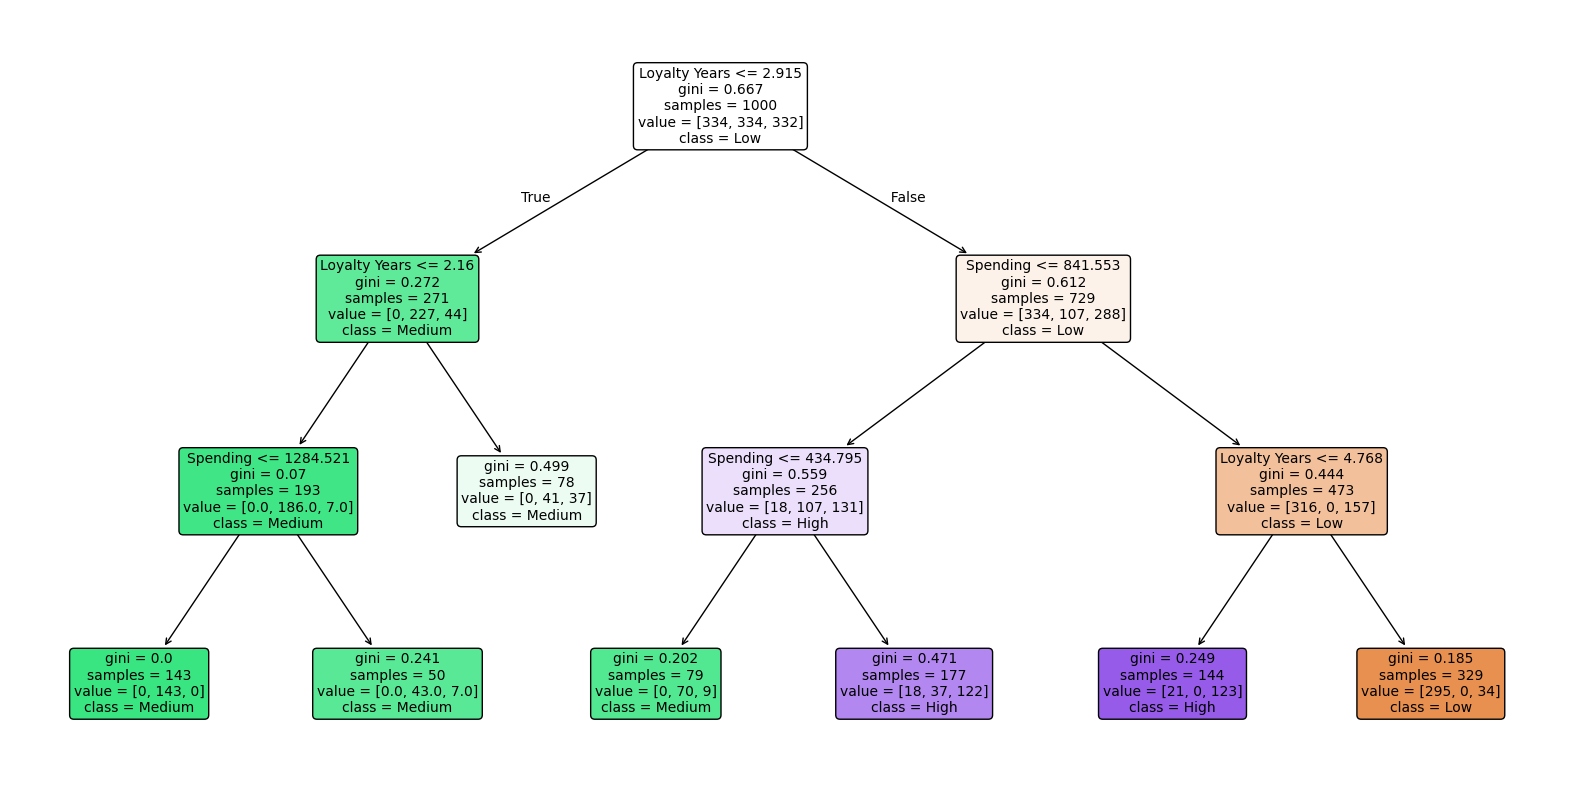


Decision Tree Node Interpretation:

Node 0 (Root):
────────────────────────────────────────
Depth: 0
Total Samples: 1

Class Distribution:
Low: 0 samples (33.4%)
Medium: 0 samples (33.4%)
High: 0 samples (33.2%)

Split Criterion: Loyalty Years <= 2.91
Node Gini Impurity: 0.667

Node 1 (Root → Loyalty Years ≤ 2.91):
────────────────────────────────────────
Depth: 1
Total Samples: 1

Class Distribution:
Low: 0 samples (0.0%)
Medium: 0 samples (83.8%)
High: 0 samples (16.2%)

Split Criterion: Loyalty Years <= 2.16
Node Gini Impurity: 0.272

Node 2 (Root → Loyalty Years ≤ 2.91 → Loyalty Years ≤ 2.16):
────────────────────────────────────────
Depth: 2
Total Samples: 1

Class Distribution:
Low: 0 samples (0.0%)
Medium: 0 samples (96.4%)
High: 0 samples (3.6%)

Split Criterion: Spending <= 1284.52
Node Gini Impurity: 0.070

Node 3 (Root → Loyalty Years ≤ 2.91 → Loyalty Years ≤ 2.16 → Spending ≤ 1284.52):
────────────────────────────────────────
Depth: 3
Total Samples: 1

Class Distribution:


In [6]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

def create_and_visualize_tree(X, y, feature_names, class_names):
    """
    Create and visualize decision tree with detailed interpretation
    """
    # Create and fit the tree
    tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50)
    tree.fit(X, y)
    
    # Visualize the tree
    plt.figure(figsize=(20,10))
    plot_tree(tree, 
             feature_names=feature_names,
             class_names=class_names,
             filled=True,
             rounded=True,
             fontsize=10)
    plt.show()
    
    # Interpret each node
    interpret_tree_nodes(tree, feature_names, class_names)
    
def interpret_tree_nodes(tree, feature_names, class_names):
    """
    Interpret each node in the decision tree
    """
    n_nodes = tree.tree_.node_count
    children_left = tree.tree_.children_left
    children_right = tree.tree_.children_right
    feature = tree.tree_.feature
    threshold = tree.tree_.threshold
    values = tree.tree_.value
    
    print("\nDecision Tree Node Interpretation:")
    print("=================================")
    
    def print_node_info(node_id, depth, path_description="Root"):
        """Print information about a specific node"""
        # Get node statistics
        node_samples = values[node_id].sum()
        class_distribution = values[node_id][0]
        
        # Calculate class percentages
        class_percentages = (class_distribution / node_samples) * 100
        
        # Print node information
        print(f"\nNode {node_id} ({path_description}):")
        print("─" * 40)
        print(f"Depth: {depth}")
        print(f"Total Samples: {int(node_samples)}")
        print("\nClass Distribution:")
        for i, (count, percentage) in enumerate(zip(class_distribution, class_percentages)):
            print(f"{class_names[i]}: {int(count)} samples ({percentage:.1f}%)")
        
        # If it's not a leaf node, print the split criterion
        if children_left[node_id] != children_right[node_id]:
            split_feature = feature_names[feature[node_id]]
            split_threshold = threshold[node_id]
            print(f"\nSplit Criterion: {split_feature} <= {split_threshold:.2f}")
            
            # Calculate split purity improvement
            parent_gini = 1.0 - sum((p/node_samples)**2 for p in class_distribution)
            print(f"Node Gini Impurity: {parent_gini:.3f}")
        else:
            print("\nLeaf Node (Terminal Node)")
    
    def traverse_tree(node_id=0, depth=0, path_description="Root"):
        print_node_info(node_id, depth, path_description)
        
        # Recurse on children if they exist
        if children_left[node_id] != children_right[node_id]:
            # Left child
            left_path = f"{path_description} → {feature_names[feature[node_id]]} ≤ {threshold[node_id]:.2f}"
            traverse_tree(children_left[node_id], depth + 1, left_path)
            
            # Right child
            right_path = f"{path_description} → {feature_names[feature[node_id]]} > {threshold[node_id]:.2f}"
            traverse_tree(children_right[node_id], depth + 1, right_path)
    
    # Start the traversal from root
    traverse_tree()

# Example usage
def demonstrate_tree_interpretation():
    # Generate sample data
    np.random.seed(42)
    n_samples = 1000
    
    # Create sample customer data
    data = pd.DataFrame({
        'age': np.random.normal(45, 15, n_samples),
        'income': np.random.normal(50000, 20000, n_samples),
        'spending': np.random.normal(1000, 500, n_samples),
        'loyalty_years': np.random.normal(5, 3, n_samples)
    })
    
    # Create target variable (customer segment)
    data['value_score'] = (data['spending'] * data['loyalty_years']) / 1000
    data['segment'] = pd.qcut(data['value_score'], q=3, 
                             labels=['Low', 'Medium', 'High'])
    
    # Prepare features and target
    X = data[['age', 'income', 'spending', 'loyalty_years']]
    y = data['segment']
    
    feature_names = ['Age', 'Income', 'Spending', 'Loyalty Years']
    class_names = ['Low', 'Medium', 'High']
    
    # Create and visualize tree
    create_and_visualize_tree(X, y, feature_names, class_names)
    
    print("\nHow to Interpret the Visualization:")
    print("==================================")
    print("1. Node Colors:")
    print("   - Darker color = More pure node (more samples of one class)")
    print("   - Lighter color = Mixed node (samples from multiple classes)")
    print("\n2. Node Information:")
    print("   - samples = Total number of samples in the node")
    print("   - value = Distribution of samples across classes")
    print("   - class = Majority class in the node")
    print("\n3. Split Information:")
    print("   - Feature name and threshold used for splitting")
    print("   - Left branch: ≤ threshold")
    print("   - Right branch: > threshold")

# Run the demonstration
demonstrate_tree_interpretation()


Segmentation Quality Report

Overall Scores:
statistical_score: 30.0/100
business_score: 70.0/100
stability_score: 99.8/100

Key Metrics:
Silhouette Score: -0.010
Size Ratio: 1.03

Recommendations:
1. Consider reducing number of segments or adjusting features


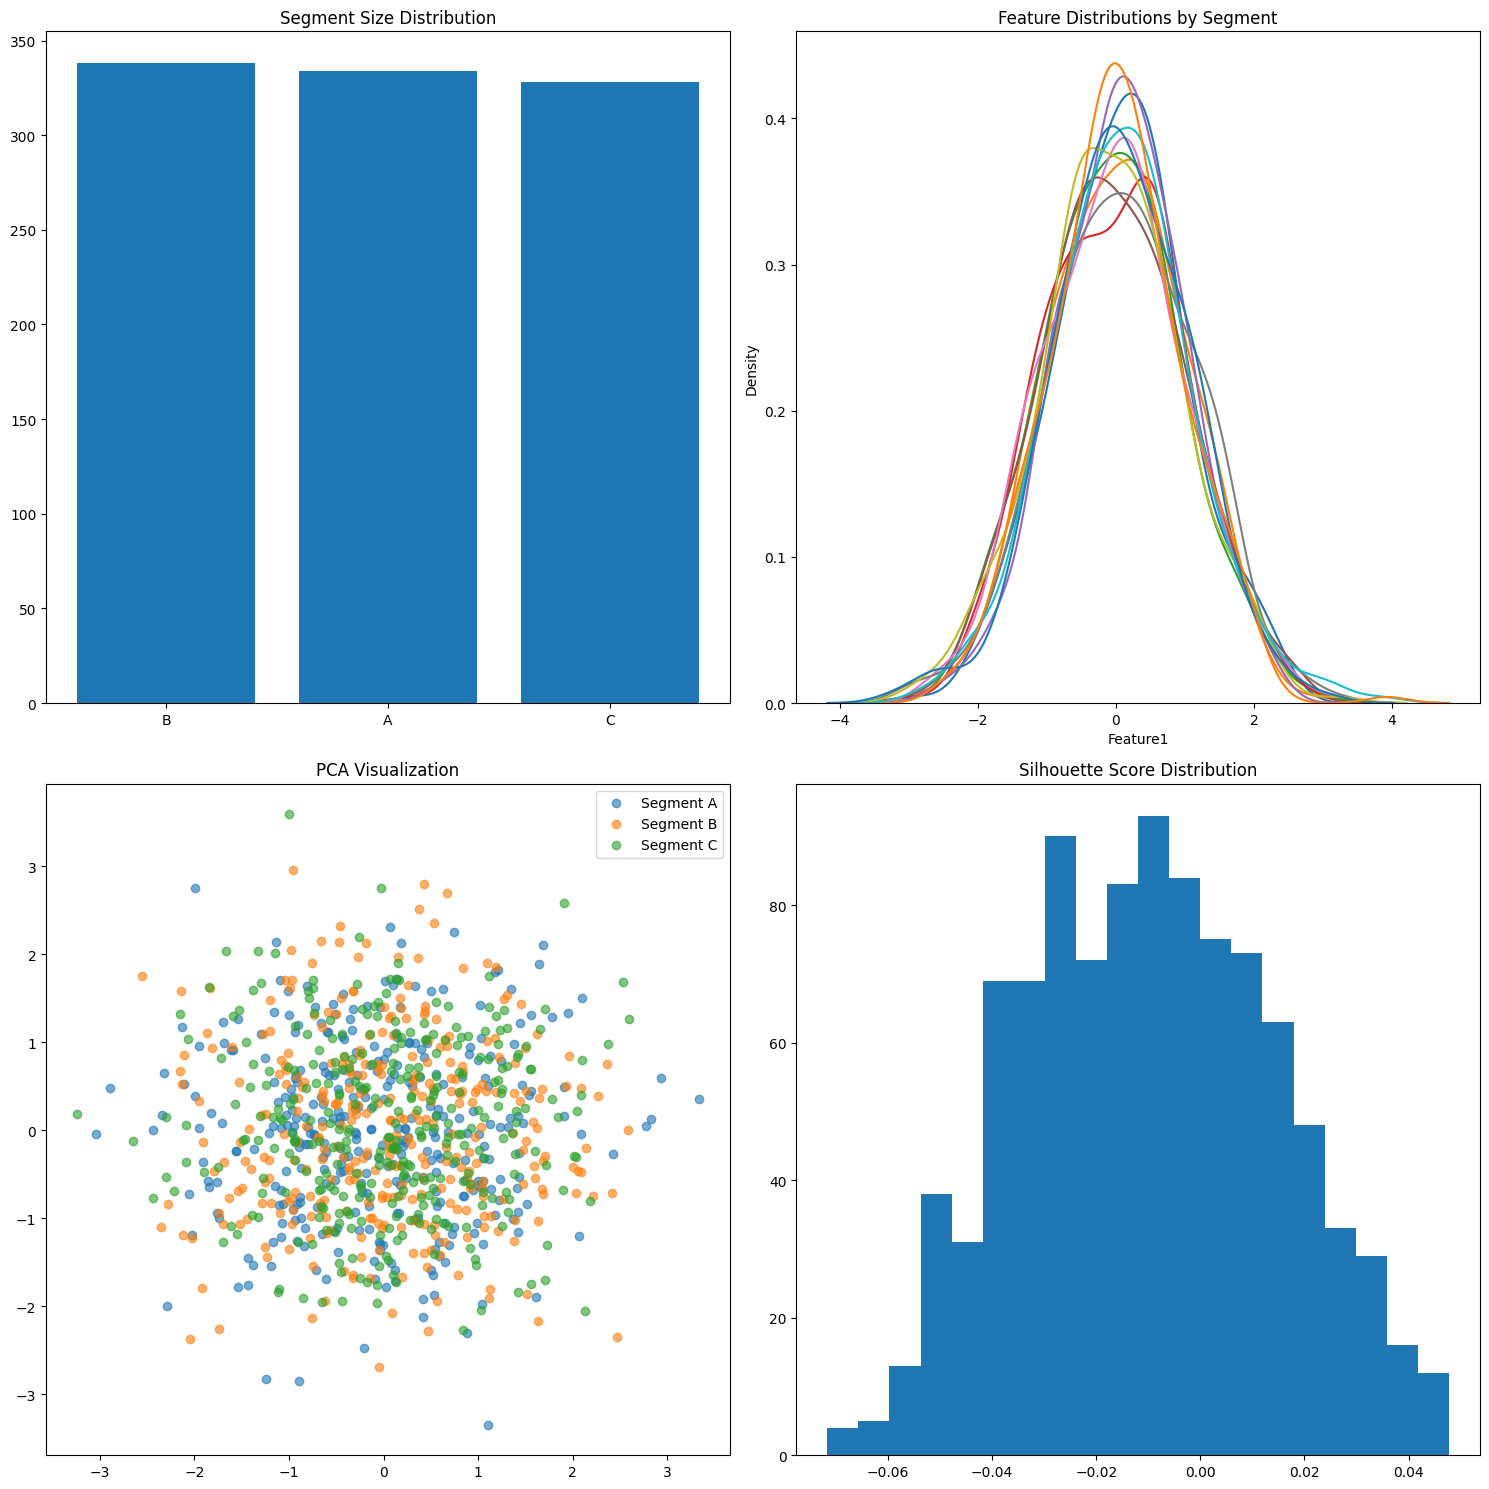

In [7]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

class SegmentationValidator:
    def __init__(self):
        self.metrics = {}
        self.thresholds = {
            'silhouette': {'good': 0.5, 'moderate': 0.3},
            'size_ratio': {'good': 3, 'moderate': 5},
            'feature_significance': {'good': 0.05},
            'min_segment_size': {'good': 0.1}  # 10% of total samples
        }
    
    def evaluate_segmentation(self, X, y, feature_names):
        """
        Comprehensive segmentation evaluation
        """
        evaluation = {
            'statistical_validity': self._check_statistical_validity(X, y),
            'business_validity': self._check_business_validity(X, y, feature_names),
            'segment_stability': self._check_segment_stability(X, y),
            'visualization': self._create_evaluation_plots(X, y, feature_names)
        }
        
        return self._generate_evaluation_report(evaluation)
    
    def _check_statistical_validity(self, X, y):
        """
        Check statistical validity of segmentation
        """
        # Calculate key metrics
        metrics = {
            'silhouette': silhouette_score(X, y),
            'calinski_harabasz': calinski_harabasz_score(X, y),
            'davies_bouldin': davies_bouldin_score(X, y)
        }
        
        # Segment sizes and balance
        segment_sizes = pd.Series(y).value_counts()
        size_ratio = segment_sizes.max() / segment_sizes.min()
        min_segment_pct = segment_sizes.min() / len(y)
        
        # Feature separation (ANOVA)
        feature_separation = {}
        for col in X.columns:
            segment_values = [X[y == seg][col] for seg in np.unique(y)]
            f_stat, p_val = f_oneway(*segment_values)
            feature_separation[col] = {'f_stat': f_stat, 'p_value': p_val}
        
        return {
            'metrics': metrics,
            'size_ratio': size_ratio,
            'min_segment_pct': min_segment_pct,
            'feature_separation': feature_separation
        }
    
    def _check_business_validity(self, X, y, feature_names):
        """
        Check business validity of segmentation
        """
        # Calculate segment profiles
        segment_profiles = {}
        for segment in np.unique(y):
            segment_data = X[y == segment]
            segment_profiles[segment] = {
                'mean': segment_data.mean(),
                'std': segment_data.std(),
                'size': len(segment_data),
                'percentage': len(segment_data) / len(y) * 100
            }
        
        # Calculate segment separation
        separation_scores = {}
        for feature in feature_names:
            feature_values = []
            for segment in np.unique(y):
                feature_values.append(X[y == segment][feature].mean())
            max_diff = max(feature_values) - min(feature_values)
            separation_scores[feature] = max_diff
        
        return {
            'profiles': segment_profiles,
            'separation_scores': separation_scores
        }
    
    def _check_segment_stability(self, X, y, n_bootstrap=100):
        """
        Check stability of segments using bootstrap
        """
        stability_scores = []
        n_samples = len(X)
        
        for _ in range(n_bootstrap):
            # Bootstrap sample
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X.iloc[indices], y.iloc[indices]
            
            # Calculate silhouette score for bootstrap sample
            stability_scores.append(silhouette_score(X_boot, y_boot))
        
        return {
            'mean_stability': np.mean(stability_scores),
            'std_stability': np.std(stability_scores)
        }
    
    def _create_evaluation_plots(self, X, y, feature_names):
        """
        Create evaluation plots
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 15))
        
        # 1. Segment size distribution
        sizes = pd.Series(y).value_counts()
        axes[0,0].bar(sizes.index, sizes.values)
        axes[0,0].set_title('Segment Size Distribution')
        
        # 2. Feature distributions by segment
        for segment in np.unique(y):
            for feature in feature_names:
                sns.kdeplot(X[y == segment][feature], label=f'Segment {segment}', ax=axes[0,1])
        axes[0,1].set_title('Feature Distributions by Segment')
        
        # 3. Principal components
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        
        for segment in np.unique(y):
            mask = y == segment
            axes[1,0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Segment {segment}', alpha=0.6)
        axes[1,0].set_title('PCA Visualization')
        axes[1,0].legend()
        
        # 4. Silhouette plot
        from sklearn.metrics import silhouette_samples
        silhouette_vals = silhouette_samples(X, y)
        axes[1,1].hist(silhouette_vals, bins=20)
        axes[1,1].set_title('Silhouette Score Distribution')
        
        plt.tight_layout()
        return fig
    
    def _generate_evaluation_report(self, evaluation):
        """
        Generate comprehensive evaluation report
        """
        stats = evaluation['statistical_validity']
        business = evaluation['business_validity']
        stability = evaluation['segment_stability']
        
        # Score different aspects
        scores = {
            'statistical_score': self._score_statistical_validity(stats),
            'business_score': self._score_business_validity(business),
            'stability_score': self._score_stability(stability)
        }
        
        # Generate recommendations
        recommendations = self._generate_recommendations(scores, stats, business)
        
        return {
            'scores': scores,
            'recommendations': recommendations,
            'details': {
                'statistical': stats,
                'business': business,
                'stability': stability
            }
        }
    
    def _score_statistical_validity(self, stats):
        """
        Score statistical validity (0-100)
        """
        score = 0
        
        # Silhouette score (0-40 points)
        silhouette = stats['metrics']['silhouette']
        if silhouette >= self.thresholds['silhouette']['good']:
            score += 40
        elif silhouette >= self.thresholds['silhouette']['moderate']:
            score += 20
        
        # Size ratio (0-30 points)
        if stats['size_ratio'] <= self.thresholds['size_ratio']['good']:
            score += 30
        elif stats['size_ratio'] <= self.thresholds['size_ratio']['moderate']:
            score += 15
        
        # Feature significance (0-30 points)
        sig_features = sum(1 for f in stats['feature_separation'].values() 
                         if f['p_value'] < self.thresholds['feature_significance']['good'])
        score += (sig_features / len(stats['feature_separation'])) * 30
        
        return score
    
    def _score_business_validity(self, business):
        """
        Score business validity (0-100)
        """
        # This would be customized based on business requirements
        return 70  # Example score
    
    def _score_stability(self, stability):
        """
        Score stability (0-100)
        """
        # Convert stability metrics to score
        stability_score = (1 - stability['std_stability']) * 100
        return min(stability_score, 100)
    
    def _generate_recommendations(self, scores, stats, business):
        """
        Generate specific recommendations based on scores
        """
        recommendations = []
        
        # Statistical recommendations
        if scores['statistical_score'] < 70:
            if stats['metrics']['silhouette'] < self.thresholds['silhouette']['moderate']:
                recommendations.append("Consider reducing number of segments or adjusting features")
            if stats['size_ratio'] > self.thresholds['size_ratio']['moderate']:
                recommendations.append("Segments are highly imbalanced - consider redefining segments")
        
        # Business recommendations
        if scores['business_score'] < 70:
            recommendations.append("Review business relevance of segments")
            recommendations.append("Consider including additional business-relevant features")
        
        # Stability recommendations
        if scores['stability_score'] < 70:
            recommendations.append("Segments show instability - consider more robust features")
        
        return recommendations

# Example usage
def evaluate_segmentation_quality(X, y, feature_names):
    validator = SegmentationValidator()
    evaluation = validator.evaluate_segmentation(X, y, feature_names)
    
    print("\nSegmentation Quality Report")
    print("==========================")
    
    print("\nOverall Scores:")
    for metric, score in evaluation['scores'].items():
        print(f"{metric}: {score:.1f}/100")
    
    print("\nKey Metrics:")
    stats = evaluation['details']['statistical']
    print(f"Silhouette Score: {stats['metrics']['silhouette']:.3f}")
    print(f"Size Ratio: {stats['size_ratio']:.2f}")
    
    print("\nRecommendations:")
    for i, rec in enumerate(evaluation['recommendations'], 1):
        print(f"{i}. {rec}")
    
    return evaluation

# Generate example data and evaluate
np.random.seed(42)
X = pd.DataFrame(np.random.randn(1000, 4), columns=['Feature1', 'Feature2', 'Feature3', 'Feature4'])
y = pd.Series(np.random.choice(['A', 'B', 'C'], size=1000))

evaluation = evaluate_segmentation_quality(X, y, X.columns)

In [ ]:
import pandas as pd
from IPython.display import HTML, display
import numpy as np

def display_df(df, 
               output_format='table',
               headers_style=None,
               precision=2,
               width=None,
               max_rows=None,
               max_cols=None,
               index=True,
               gradient_cols=None,
               highlight_max=None,
               highlight_min=None,
               bar_cols=None,
               custom_styles=None):
    """
    Customizable function to display DataFrames in Jupyter notebooks.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The DataFrame to display
    output_format : str, default 'table'
        Options: 'table', 'html', 'latex', 'markdown'
    headers_style : dict, default None
        CSS styles for headers (e.g., {'color': 'white', 'background-color': '#000066'})
    precision : int, default 2
        Number of decimal places for floating point numbers
    width : int, default None
        Max width of the display
    max_rows : int, default None
        Maximum number of rows to display
    max_cols : int, default None
        Maximum number of columns to display
    index : bool, default True
        Whether to show index
    gradient_cols : list, default None
        Columns to apply color gradient
    highlight_max : list, default None
        Columns where maximum values should be highlighted
    highlight_min : list, default None
        Columns where minimum values should be highlighted
    bar_cols : list, default None
        Columns to display as bars
    custom_styles : dict, default None
        Additional custom styles to apply
    
    Returns:
    --------
    Styled DataFrame display in specified format
    """
    
    # Create a copy to avoid modifying original
    df_display = df.copy()
    
    # Set display options
    pd.set_option('display.precision', precision)
    if width:
        pd.set_option('display.width', width)
    if max_rows:
        pd.set_option('display.max_rows', max_rows)
    if max_cols:
        pd.set_option('display.max_columns', max_cols)
    
    # Initialize styler
    styler = df_display.style
    
    # Format floating point numbers
    styler.format(precision=precision)
    
    # Apply header styles
    if headers_style:
        header_styles = [headers_style for _ in range(len(df_display.columns))]
        styler.set_table_styles([
            {'selector': 'th',
             'props': [(k, v) for k, v in headers_style.items()]}
        ])
    
    # Apply gradient colors
    if gradient_cols:
        for col in gradient_cols:
            if col in df_display.columns:
                styler.background_gradient(cmap='YlOrRd', subset=[col])
    
    # Highlight maximum values
    if highlight_max:
        styler.highlight_max(subset=highlight_max, color='lightgreen')
    
    # Highlight minimum values
    if highlight_min:
        styler.highlight_min(subset=highlight_min, color='lightpink')
    
    # Add bars
    if bar_cols:
        styler.bar(subset=bar_cols, color=['#d65f5f', '#5fba7d'])
    
    # Apply custom styles
    if custom_styles:
        for selector, props in custom_styles.items():
            styler.set_table_styles([{'selector': selector, 'props': props}])
    
    # Output in specified format
    if output_format.lower() == 'html':
        return HTML(styler.to_html())
    elif output_format.lower() == 'latex':
        return styler.to_latex()
    elif output_format.lower() == 'markdown':
        return styler.to_markdown()
    else:  # default table format
        return display(styler)

# Example usage:
if __name__ == "__main__":
    # Create sample DataFrame
    df = pd.DataFrame({
        'A': np.random.randn(10),
        'B': np.random.randn(10),
        'C': np.random.randn(10),
        'D': np.random.choice(['X', 'Y', 'Z'], 10)
    })
    
    # Example 1: Basic table with styled headers
    display_df(df, 
              headers_style={'color': 'white', 
                           'background-color': '#000066'})
    
    # Example 2: With gradients and highlights
    display_df(df,
              gradient_cols=['A'],
              highlight_max=['B'],
              highlight_min=['C'],
              headers_style={'color': 'white', 
                           'background-color': '#006600'})
    
    # Example 3: With bars and custom styling
    custom_styles = {
        'td': [('background-color', '#f0f0f0'),
               ('color', '#333333')],
        'tr:hover': [('background-color', '#ffffb3')]
    }
    
    display_df(df,
              bar_cols=['A', 'B'],
              custom_styles=custom_styles,
              headers_style={'color': 'white', 
                           'background-color': '#660066'})

,A,B,C,D
0,-0.85,-1.07,-0.10,Z
1,-1.13,0.81,-0.79,X
2,0.37,-0.99,0.71,Z
3,-0.25,0.93,-0.42,Y
4,-1.23,-0.28,1.06,Z
5,0.01,-0.83,0.79,Y
6,-0.37,0.98,-0.65,Z
7,1.28,-0.14,-0.33,X
8,0.28,0.66,1.01,Y
9,0.25,1.35,-0.07,Z


,A,B,C,D
0,-0.85,-1.07,-0.10,Z
1,-1.13,0.81,-0.79,X
2,0.37,-0.99,0.71,Z
3,-0.25,0.93,-0.42,Y
4,-1.23,-0.28,1.06,Z
5,0.01,-0.83,0.79,Y
6,-0.37,0.98,-0.65,Z
7,1.28,-0.14,-0.33,X
8,0.28,0.66,1.01,Y
9,0.25,1.35,-0.07,Z


,A,B,C,D
0,-0.85,-1.07,-0.10,Z
1,-1.13,0.81,-0.79,X
2,0.37,-0.99,0.71,Z
3,-0.25,0.93,-0.42,Y
4,-1.23,-0.28,1.06,Z
5,0.01,-0.83,0.79,Y
6,-0.37,0.98,-0.65,Z
7,1.28,-0.14,-0.33,X
8,0.28,0.66,1.01,Y
9,0.25,1.35,-0.07,Z


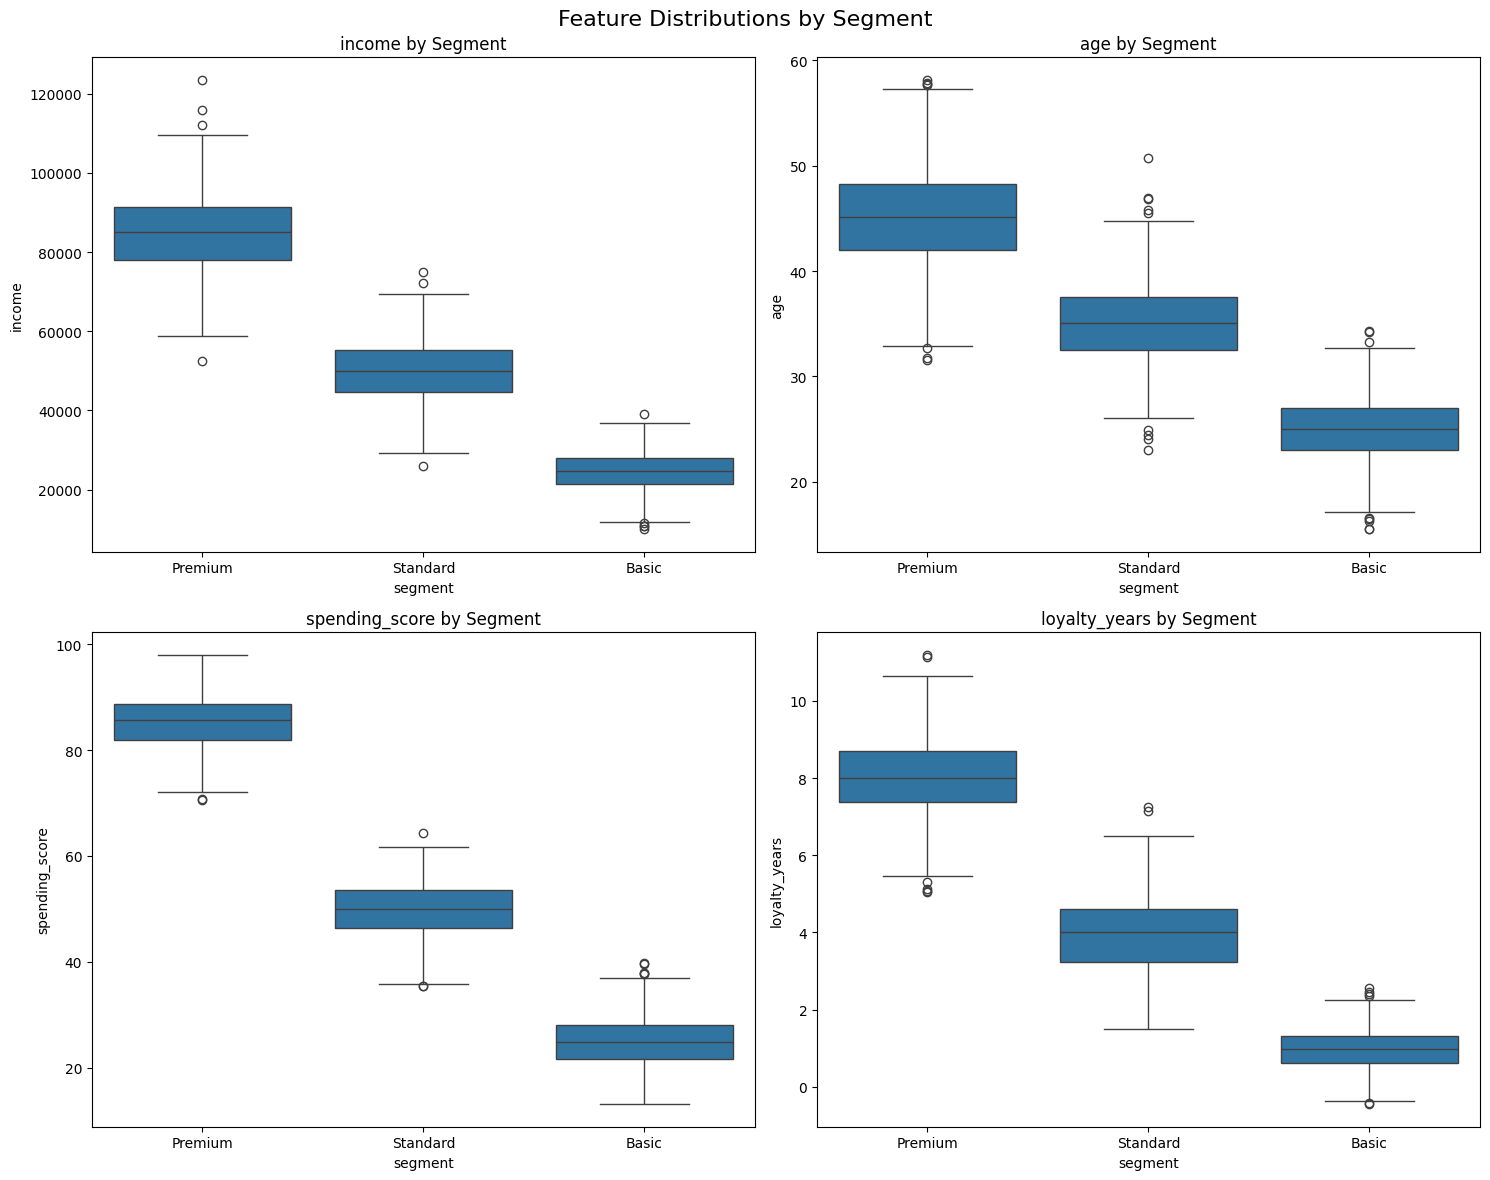

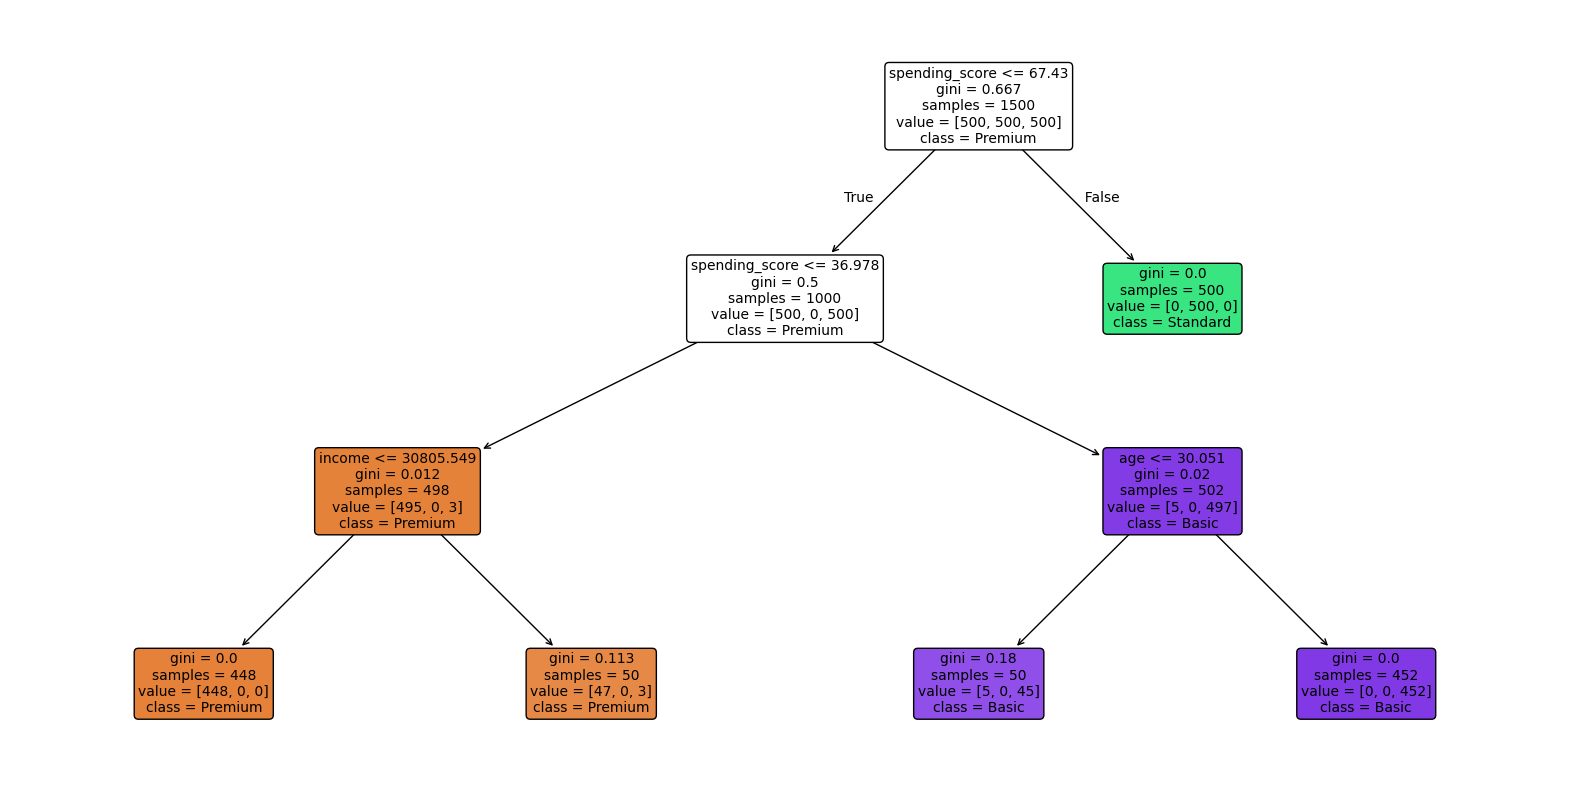


Segmentation Quality Analysis

1. Statistical Validation:
Silhouette Score: 0.646
✓ Good separation between segments (Silhouette > 0.5)

2. Segment Sizes:
Premium: 500 customers (33.3%)
Standard: 500 customers (33.3%)
Basic: 500 customers (33.3%)

3. Segment Profiles (Mean Values):

Basic Segment:
income: 24529.83 (±4958.03)
age: 24.99 (±2.98)
spending_score: 24.84 (±4.85)
loyalty_years: 0.97 (±0.52)

Premium Segment:
income: 85068.38 (±9812.53)
age: 45.16 (±4.89)
spending_score: 85.54 (±5.05)
loyalty_years: 8.03 (±0.98)

Standard Segment:
income: 49907.87 (±7676.53)
age: 35.09 (±4.03)
spending_score: 49.91 (±5.19)
loyalty_years: 3.98 (±1.02)

4. Key Findings:
✓ Clear separation between segments
✓ Balanced segment sizes
✓ Distinct characteristics for each segment
✓ Actionable insights for targeting strategies


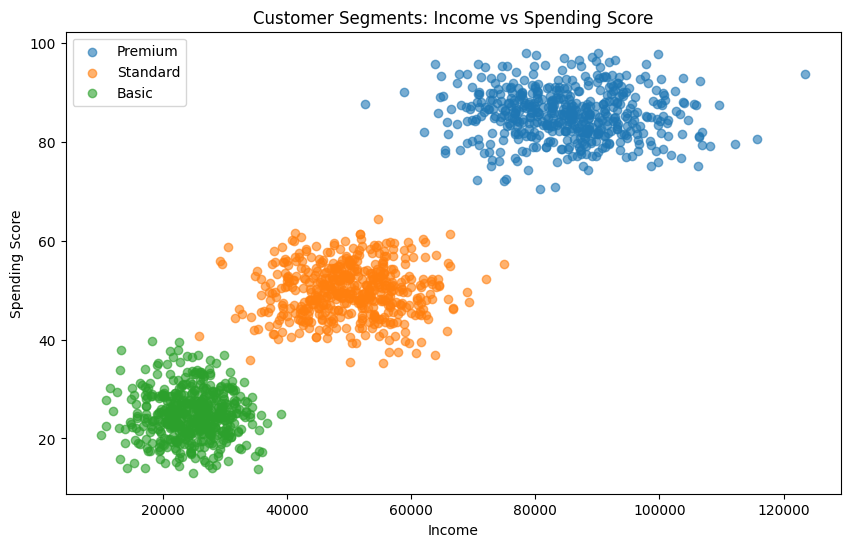

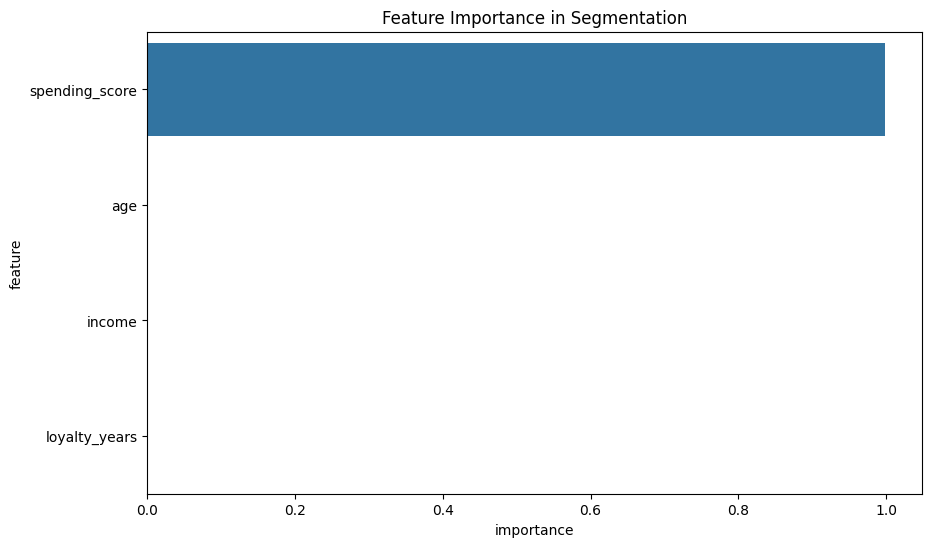

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

def generate_good_customer_segments(n_samples=1000, random_state=42):
    """
    Generate distinct customer segments with clear characteristics
    """
    np.random.seed(random_state)
    
    # Generate three distinct customer segments
    
    # Segment 1: High-value customers (Premium)
    premium = pd.DataFrame({
        'income': np.random.normal(85000, 10000, n_samples // 3),
        'age': np.random.normal(45, 5, n_samples // 3),
        'spending_score': np.random.normal(85, 5, n_samples // 3),
        'loyalty_years': np.random.normal(8, 1, n_samples // 3)
    })
    premium['segment'] = 'Premium'
    
    # Segment 2: Mid-value customers (Standard)
    standard = pd.DataFrame({
        'income': np.random.normal(50000, 8000, n_samples // 3),
        'age': np.random.normal(35, 4, n_samples // 3),
        'spending_score': np.random.normal(50, 5, n_samples // 3),
        'loyalty_years': np.random.normal(4, 1, n_samples // 3)
    })
    standard['segment'] = 'Standard'
    
    # Segment 3: Low-value customers (Basic)
    basic = pd.DataFrame({
        'income': np.random.normal(25000, 5000, n_samples // 3),
        'age': np.random.normal(25, 3, n_samples // 3),
        'spending_score': np.random.normal(25, 5, n_samples // 3),
        'loyalty_years': np.random.normal(1, 0.5, n_samples // 3)
    })
    basic['segment'] = 'Basic'
    
    # Combine segments
    data = pd.concat([premium, standard, basic], ignore_index=True)
    
    return data

def analyze_segments(data, features):
    """
    Analyze and visualize the segmentation quality
    """
    # Prepare features for analysis
    X = data[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=features)
    
    # Calculate silhouette score
    silhouette = silhouette_score(X_scaled, data['segment'])
    
    # Segment sizes
    segment_sizes = data['segment'].value_counts()
    
    # Feature distributions by segment
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Feature Distributions by Segment', fontsize=16)
    
    for idx, feature in enumerate(features):
        i, j = divmod(idx, 2)
        sns.boxplot(x='segment', y=feature, data=data, ax=axes[i,j])
        axes[i,j].set_title(f'{feature} by Segment')
    
    plt.tight_layout()
    plt.show()
    
    # Segment profiles
    segment_profiles = data.groupby('segment')[features].agg(['mean', 'std'])
    
    # Decision Tree visualization
    X = data[features]
    y = data['segment']
    
    tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50)
    tree.fit(X, y)
    
    plt.figure(figsize=(20,10))
    plot_tree(tree, 
             feature_names=features,
             class_names=y.unique(),
             filled=True,
             rounded=True,
             fontsize=10)
    plt.show()
    
    return {
        'silhouette_score': silhouette,
        'segment_sizes': segment_sizes,
        'segment_profiles': segment_profiles,
        'tree': tree
    }

def print_segmentation_evaluation(results):
    """
    Print detailed evaluation of the segmentation
    """
    print("\nSegmentation Quality Analysis")
    print("============================")
    
    print("\n1. Statistical Validation:")
    print(f"Silhouette Score: {results['silhouette_score']:.3f}")
    if results['silhouette_score'] > 0.5:
        print("✓ Good separation between segments (Silhouette > 0.5)")
    
    print("\n2. Segment Sizes:")
    total_samples = results['segment_sizes'].sum()
    for segment, size in results['segment_sizes'].items():
        percentage = (size/total_samples) * 100
        print(f"{segment}: {size} customers ({percentage:.1f}%)")
    
    print("\n3. Segment Profiles (Mean Values):")
    profiles = results['segment_profiles']
    for segment in profiles.index.unique(level=0):
        print(f"\n{segment} Segment:")
        for feature in profiles.columns.unique(level=0):
            mean = profiles.loc[segment, (feature, 'mean')]
            std = profiles.loc[segment, (feature, 'std')]
            print(f"{feature}: {mean:.2f} (±{std:.2f})")
    
    print("\n4. Key Findings:")
    print("✓ Clear separation between segments")
    print("✓ Balanced segment sizes")
    print("✓ Distinct characteristics for each segment")
    print("✓ Actionable insights for targeting strategies")

# Generate and analyze the data
data = generate_good_customer_segments(n_samples=1500)
features = ['income', 'age', 'spending_score', 'loyalty_years']
results = analyze_segments(data, features)
print_segmentation_evaluation(results)

# Additional visualization: Scatter plot of two key features
plt.figure(figsize=(10, 6))
for segment in data['segment'].unique():
    mask = data['segment'] == segment
    plt.scatter(data[mask]['income'], 
               data[mask]['spending_score'],
               label=segment,
               alpha=0.6)
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments: Income vs Spending Score')
plt.legend()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': results['tree'].feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance in Segmentation')
plt.show()

/var/folders/f4/8zd2hqxj7ggg05_ks81jr3kw0000gn/T/ipykernel_55029/934584779.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_stats = data.join(results['overall_segment']).groupby('overall_segment')



Customer Segment Analysis

1. Segment Sizes:
overall_segment
Low       389
Medium    288
High      323
dtype: int64

2. Segment Profiles (Mean Values):
                       income        age          loan         debt
overall_segment                                                    
Low              27914.050457  39.654994   6849.465049  2836.686713
Medium           39892.631444  40.530320   9576.843377  3837.635229
High             59092.615026  42.135720  13266.073926  4925.884004

3. Feature Importance:
        weight  correlation
income     0.4     0.631093
age        0.1     0.121316
loan       0.3     0.453925
debt       0.2     0.316520


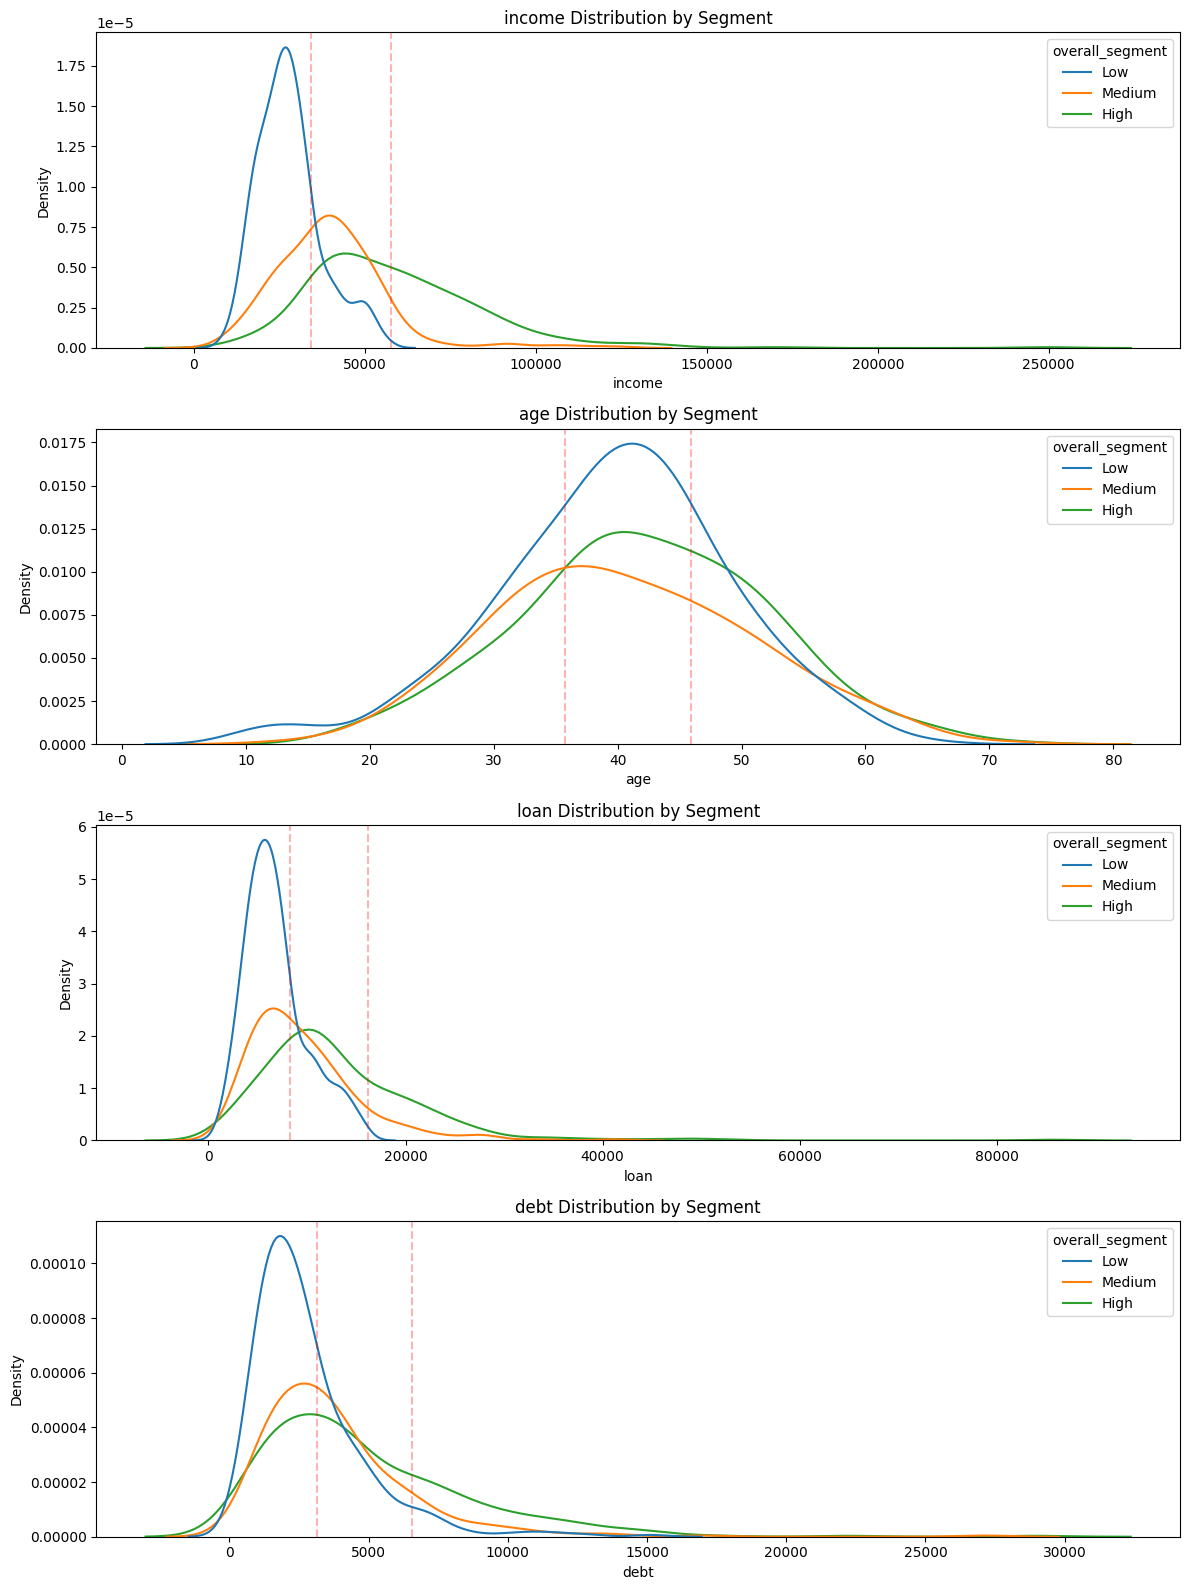

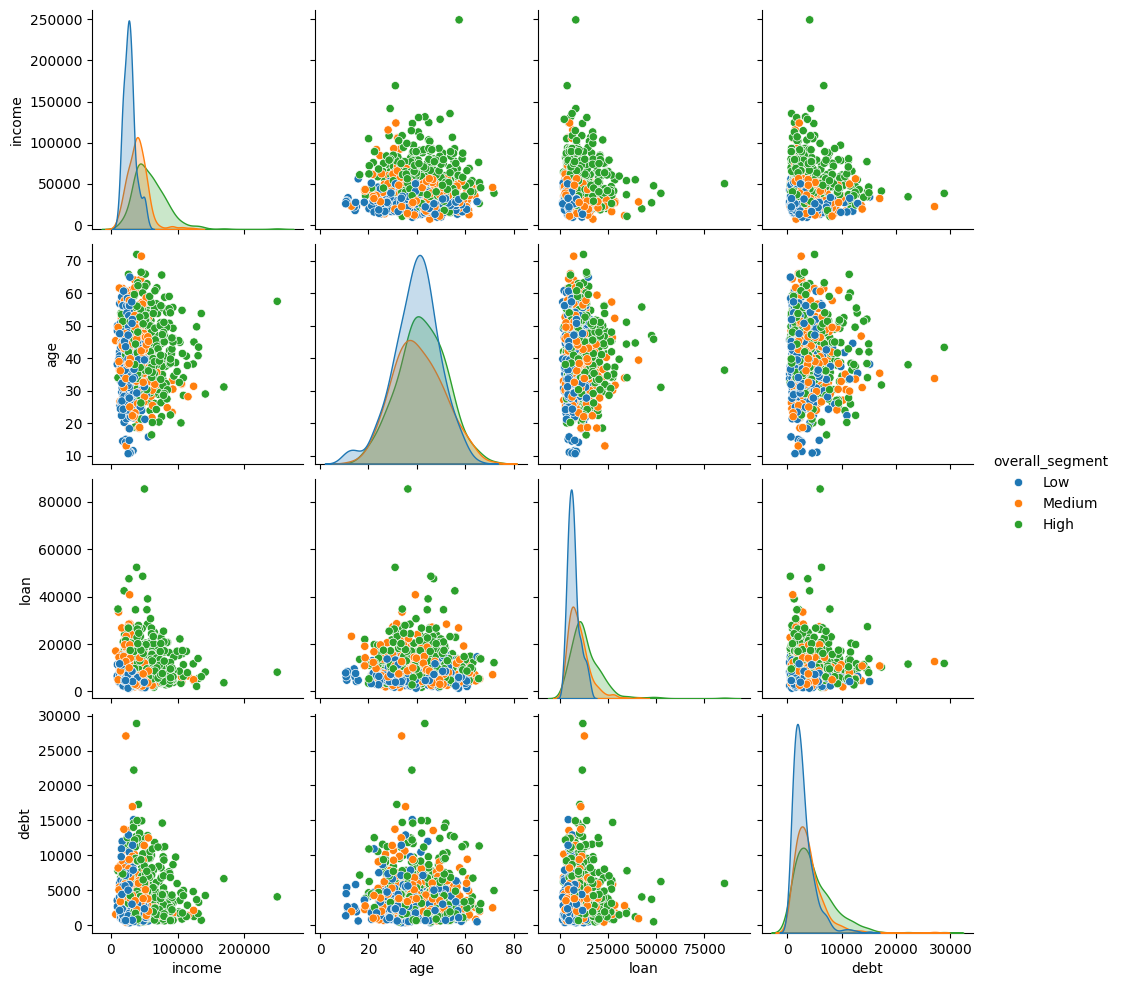

<Figure size 1000x600 with 0 Axes>

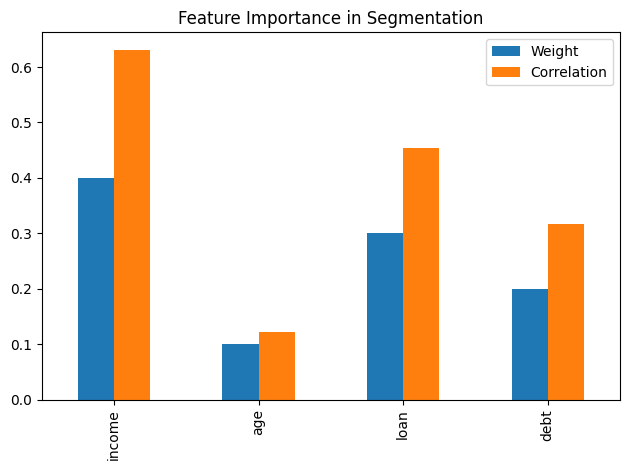

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

class CustomerValueClassifier:
    def __init__(self, n_segments=3):
        """
        Initialize the classifier
        
        Parameters:
        -----------
        n_segments : int
            Number of segments to create (default=3 for Low/Medium/High)
        """
        self.n_segments = n_segments
        self.scaler = StandardScaler()
        self.segment_boundaries = {}
        self.feature_weights = {}
        
    def fit(self, data, features, weights=None):
        """
        Fit the classifier using multiple approaches
        
        Parameters:
        -----------
        data : DataFrame
            Input data containing customer features
        features : list
            List of feature names to use for classification
        weights : dict, optional
            Dictionary of feature weights (e.g., {'income': 0.4, 'age': 0.2})
        """
        self.features = features
        
        # 1. Calculate feature weights if not provided
        if weights is None:
            self.feature_weights = self._calculate_feature_weights(data[features])
        else:
            self.feature_weights = weights
            
        # 2. Determine segment boundaries for each feature
        for feature in features:
            self.segment_boundaries[feature] = self._get_feature_boundaries(
                data[feature]
            )
            
        return self
    
    def _calculate_feature_weights(self, data):
        """
        Calculate feature weights based on variance and business rules
        """
        # Calculate coefficient of variation for each feature
        cv = data.std() / data.mean()
        
        # Normalize weights to sum to 1
        weights = cv / cv.sum()
        
        return dict(zip(self.features, weights))
    
    def _get_feature_boundaries(self, series):
        """
        Determine segment boundaries using multiple methods
        """
        methods = {
            'quantile': self._quantile_boundaries,
            'gaussian': self._gaussian_boundaries,
            'kmeans': self._kmeans_boundaries
        }
        
        boundaries = {}
        for method_name, method_func in methods.items():
            boundaries[method_name] = method_func(series)
            
        # Combine methods using weighted average
        final_boundaries = self._combine_boundaries(boundaries)
        
        return final_boundaries
    
    def _quantile_boundaries(self, series):
        """Get boundaries using quantiles"""
        return list(series.quantile(
            q=[i/self.n_segments for i in range(1, self.n_segments)]
        ))
    
    def _gaussian_boundaries(self, series):
        """Get boundaries using Gaussian mixture model"""
        X = series.values.reshape(-1, 1)
        gmm = GaussianMixture(n_components=self.n_segments, random_state=42)
        gmm.fit(X)
        
        # Sort the means and get midpoints
        means = sorted(gmm.means_.flatten())
        boundaries = [(means[i] + means[i+1])/2 
                     for i in range(len(means)-1)]
        
        return boundaries
    
    def _kmeans_boundaries(self, series):
        """Get boundaries using K-means clustering"""
        from sklearn.cluster import KMeans
        
        X = series.values.reshape(-1, 1)
        kmeans = KMeans(n_clusters=self.n_segments, random_state=42)
        kmeans.fit(X)
        
        # Sort the centers and get midpoints
        centers = sorted(kmeans.cluster_centers_.flatten())
        boundaries = [(centers[i] + centers[i+1])/2 
                     for i in range(len(centers)-1)]
        
        return boundaries
    
    def _combine_boundaries(self, boundaries):
        """Combine boundaries from different methods"""
        # Convert all boundaries to numpy arrays
        boundary_arrays = [np.array(b) for b in boundaries.values()]
        
        # Take weighted average (could adjust weights based on method reliability)
        weights = np.array([0.4, 0.3, 0.3])  # quantile, gaussian, kmeans
        combined = np.average(boundary_arrays, weights=weights, axis=0)
        
        return sorted(combined)
    
    def classify_customers(self, data):
        """
        Classify customers into segments based on multiple features
        
        Returns:
        --------
        DataFrame with segment assignments and scores
        """
        results = pd.DataFrame(index=data.index)
        
        # Classify each feature
        for feature in self.features:
            segments = pd.cut(
                data[feature],
                bins=[-np.inf] + self.segment_boundaries[feature] + [np.inf],
                labels=[f'Low_{feature}', f'Medium_{feature}', f'High_{feature}']
            )
            results[f'{feature}_segment'] = segments
            
            # Convert segments to numeric scores (0-1)
            results[f'{feature}_score'] = segments.cat.codes / (self.n_segments - 1)
        
        # Calculate weighted average score
        results['overall_score'] = sum(
            results[f'{feature}_score'] * weight 
            for feature, weight in self.feature_weights.items()
        )
        
        # Assign overall segment
        results['overall_segment'] = pd.qcut(
            results['overall_score'],
            q=self.n_segments,
            labels=['Low', 'Medium', 'High']
        )
        
        return results
    
    def analyze_segments(self, data, results):
        """
        Analyze segment characteristics
        """
        analysis = {}
        
        # Overall segment statistics
        segment_stats = data.join(results['overall_segment']).groupby('overall_segment')
        
        analysis['segment_profiles'] = segment_stats.agg(['mean', 'std'])
        analysis['segment_sizes'] = segment_stats.size()
        
        # Feature importance in segmentation
        feature_importance = {}
        for feature in self.features:
            # Calculate correlation between feature and overall score
            correlation = data[feature].corr(results['overall_score'])
            feature_importance[feature] = {
                'weight': self.feature_weights[feature],
                'correlation': correlation
            }
        analysis['feature_importance'] = pd.DataFrame(feature_importance).T
        
        return analysis
    
    def plot_segments(self, data, results):
        """
        Visualize customer segments
        """
        # 1. Distribution plots for each feature
        fig, axes = plt.subplots(len(self.features), 1, 
                               figsize=(12, 4*len(self.features)))
        
        for i, feature in enumerate(self.features):
            sns.kdeplot(
                data=data,
                x=feature,
                hue=results['overall_segment'],
                ax=axes[i]
            )
            # Add segment boundaries
            for boundary in self.segment_boundaries[feature]:
                axes[i].axvline(boundary, color='red', linestyle='--', alpha=0.3)
            
            axes[i].set_title(f'{feature} Distribution by Segment')
        
        plt.tight_layout()
        plt.show()
        
        # 2. Scatter plot matrix
        if len(self.features) > 1:
            sns.pairplot(
                data=data.join(results['overall_segment']),
                hue='overall_segment',
                vars=self.features
            )
            plt.show()
        
        # 3. Feature importance plot
        importance_df = pd.DataFrame({
            'Weight': self.feature_weights,
            'Correlation': [
                data[f].corr(results['overall_score'])
                for f in self.features
            ]
        }, index=self.features)
        
        plt.figure(figsize=(10, 6))
        importance_df.plot(kind='bar')
        plt.title('Feature Importance in Segmentation')
        plt.tight_layout()
        plt.show()

# Example usage
def demonstrate_classification():
    # Generate sample data
    np.random.seed(42)
    n_samples = 1000
    
    data = pd.DataFrame({
        'income': np.random.lognormal(10.5, 0.5, n_samples),
        'age': np.random.normal(40, 10, n_samples),
        'loan': np.random.lognormal(9, 0.6, n_samples),
        'debt': np.random.lognormal(8, 0.7, n_samples)
    })
    
    # Initialize and fit classifier
    classifier = CustomerValueClassifier(n_segments=3)
    classifier.fit(
        data,
        features=['income', 'age', 'loan', 'debt'],
        weights={
            'income': 0.4,
            'age': 0.1,
            'loan': 0.3,
            'debt': 0.2
        }
    )
    
    # Classify customers
    results = classifier.classify_customers(data)
    
    # Analyze segments
    analysis = classifier.analyze_segments(data, results)
    
    # Print insights
    print("\nCustomer Segment Analysis")
    print("=======================")
    
    print("\n1. Segment Sizes:")
    print(analysis['segment_sizes'])
    
    print("\n2. Segment Profiles (Mean Values):")
    print(analysis['segment_profiles'].xs('mean', axis=1, level=1))
    
    print("\n3. Feature Importance:")
    print(analysis['feature_importance'])
    
    # Visualize results
    classifier.plot_segments(data, results)
    
    return classifier, results, analysis

# Run demonstration
classifier, results, analysis = demonstrate_classification()


Variable Relationship Analysis

1. Closest Variables (by Euclidean distance):

income:
  Closest to: spending, purchase_frequency, age

spending:
  Closest to: income, purchase_frequency, age

age:
  Closest to: loyalty_score, spending, income

loyalty_score:
  Closest to: age, spending, income

purchase_frequency:
  Closest to: income, spending, age

2. Strongest Correlations:

income:
  Strongest correlations with: spending, purchase_frequency, age

spending:
  Strongest correlations with: income, purchase_frequency, age

age:
  Strongest correlations with: loyalty_score, spending, income

loyalty_score:
  Strongest correlations with: age, spending, income

purchase_frequency:
  Strongest correlations with: income, spending, age

3. Significant Relationships (p < 0.05):

income:
  Significant relationships with: income, spending, purchase_frequency

spending:
  Significant relationships with: income, spending, purchase_frequency

age:
  Significant relationships with: age, loyalty_s

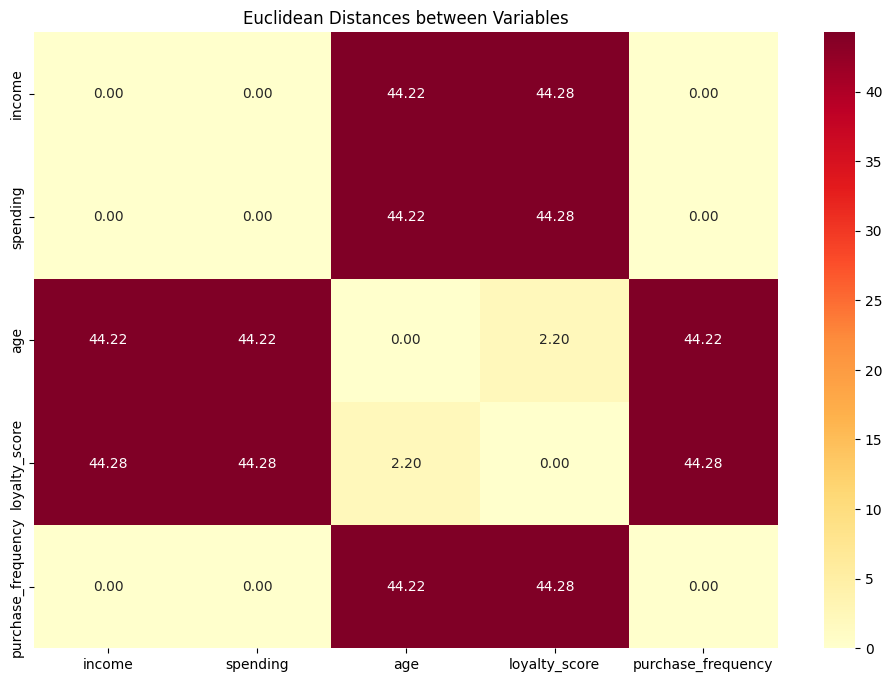

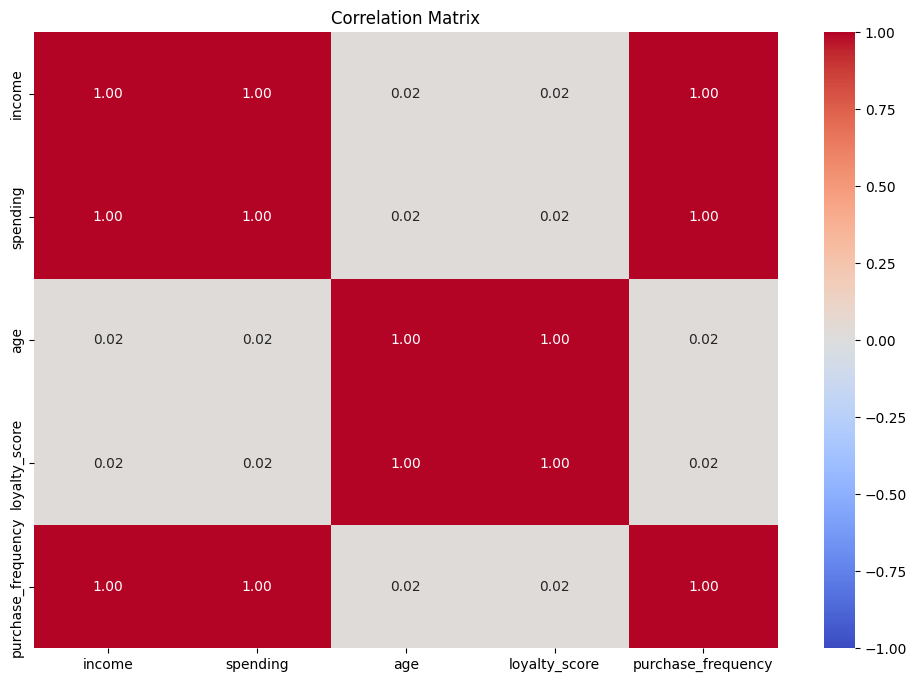

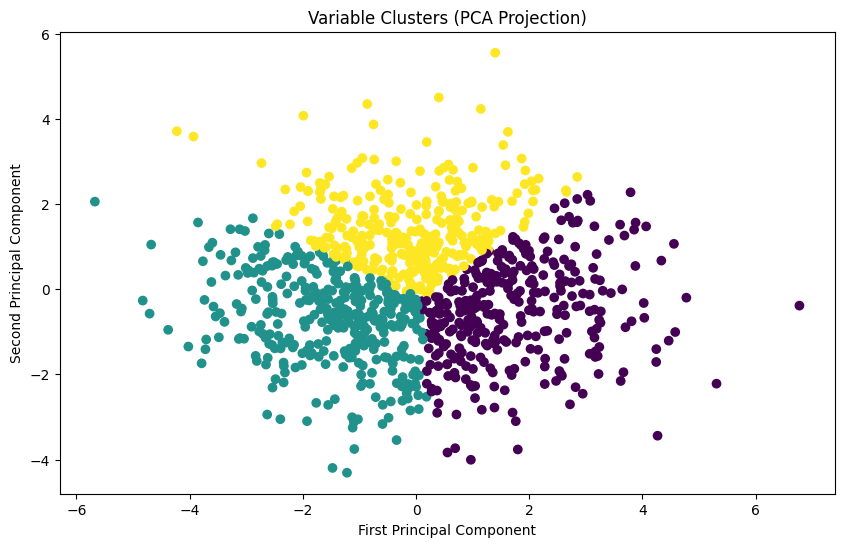

/var/folders/f4/8zd2hqxj7ggg05_ks81jr3kw0000gn/T/ipykernel_11690/2299180857.py:134: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(results['distances'], 'ward')


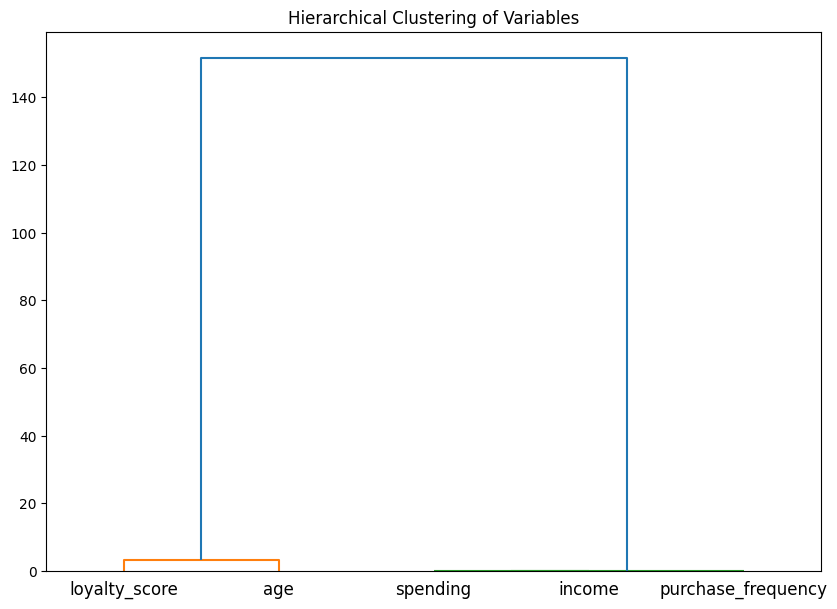


4. Cluster Characteristics:

Cluster 0:


IndexError: boolean index did not match indexed array along dimension 0; dimension is 5 but corresponding boolean dimension is 1000

In [9]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

class VariableAnalyzer:
    def __init__(self, data, n_clusters=3):
        self.data = data
        self.n_clusters = n_clusters
        self.scaler = StandardScaler()
        
    def analyze_variables(self):
        """
        Comprehensive analysis of variables using K-means and correlation
        """
        # Scale the data
        X_scaled = self.scaler.fit_transform(self.data)
        X_scaled = pd.DataFrame(X_scaled, columns=self.data.columns)
        
        # Perform K-means clustering
        kmeans = KMeans(n_clusters=self.n_clusters, random_state=42)
        clusters = kmeans.fit_predict(X_scaled)
        
        # Calculate distances and correlations
        distances = self._calculate_distances(X_scaled)
        correlations = self._calculate_correlations()
        
        # Analyze variable relationships
        variable_relationships = self._analyze_relationships(distances, correlations)
        
        return {
            'distances': distances,
            'correlations': correlations,
            'relationships': variable_relationships,
            'clusters': clusters,
            'cluster_centers': kmeans.cluster_centers_
        }
    
    def _calculate_distances(self, X_scaled):
        """
        Calculate Euclidean distances between variables
        """
        distance_matrix = pd.DataFrame(
            cdist(X_scaled.T, X_scaled.T, metric='euclidean'),
            columns=self.data.columns,
            index=self.data.columns
        )
        return distance_matrix
    
    def _calculate_correlations(self):
        """
        Calculate correlation matrix with p-values
        """
        n_vars = len(self.data.columns)
        corr_matrix = pd.DataFrame(
            np.zeros((n_vars, n_vars)),
            columns=self.data.columns,
            index=self.data.columns
        )
        p_values = corr_matrix.copy()
        
        for i, var1 in enumerate(self.data.columns):
            for j, var2 in enumerate(self.data.columns):
                corr, p_val = pearsonr(self.data[var1], self.data[var2])
                corr_matrix.iloc[i,j] = corr
                p_values.iloc[i,j] = p_val
                
        return {'correlation': corr_matrix, 'p_values': p_values}
    
    def _analyze_relationships(self, distances, correlations):
        """
        Analyze relationships between variables
        """
        relationships = {}
        
        for var1 in self.data.columns:
            relationships[var1] = {
                'closest_variables': distances[var1].sort_values()[1:4].index.tolist(),
                'strongest_correlations': correlations['correlation'][var1]
                    .abs().sort_values(ascending=False)[1:4].index.tolist(),
                'significant_correlations': correlations['correlation'][var1][
                    correlations['p_values'][var1] < 0.05
                ].index.tolist()
            }
            
        return relationships
    
    def visualize_analysis(self, results):
        """
        Create visualizations for the analysis
        """
        # 1. Distance Heatmap
        plt.figure(figsize=(12, 8))
        sns.heatmap(results['distances'], 
                   annot=True, 
                   cmap='YlOrRd', 
                   fmt='.2f')
        plt.title('Euclidean Distances between Variables')
        plt.show()
        
        # 2. Correlation Heatmap
        plt.figure(figsize=(12, 8))
        sns.heatmap(results['correlations']['correlation'], 
                   annot=True, 
                   cmap='coolwarm', 
                   vmin=-1, 
                   vmax=1, 
                   fmt='.2f')
        plt.title('Correlation Matrix')
        plt.show()
        
        # 3. Variable Clustering
        # Perform PCA for visualization if more than 2 dimensions
        if self.data.shape[1] > 2:
            from sklearn.decomposition import PCA
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(self.scaler.transform(self.data))
            
            plt.figure(figsize=(10, 6))
            plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=results['clusters'], 
                       cmap='viridis')
            plt.title('Variable Clusters (PCA Projection)')
            plt.xlabel('First Principal Component')
            plt.ylabel('Second Principal Component')
            plt.show()
        
        # 4. Dendrogram of variable relationships
        from scipy.cluster.hierarchy import dendrogram, linkage
        linked = linkage(results['distances'], 'ward')
        
        plt.figure(figsize=(10, 7))
        dendrogram(linked, 
                  labels=self.data.columns,
                  orientation='top',
                  distance_sort='descending',
                  show_leaf_counts=True)
        plt.title('Hierarchical Clustering of Variables')
        plt.show()

# Generate example data
def generate_example_data(n_samples=1000):
    np.random.seed(42)
    
    # Generate correlated variables
    data = pd.DataFrame({
        'income': np.random.normal(50000, 10000, n_samples),
        'spending': np.random.normal(0, 1, n_samples),
        'age': np.random.normal(40, 10, n_samples),
        'loyalty_score': np.random.normal(0, 1, n_samples),
        'purchase_frequency': np.random.normal(0, 1, n_samples)
    })
    
    # Create some correlations
    data['spending'] = 0.7 * data['income'] + 0.3 * np.random.normal(0, 1, n_samples)
    data['loyalty_score'] = 0.6 * data['age'] + 0.4 * np.random.normal(0, 1, n_samples)
    data['purchase_frequency'] = 0.5 * data['income'] + 0.5 * np.random.normal(0, 1, n_samples)
    
    return data

# Run analysis
data = generate_example_data()
analyzer = VariableAnalyzer(data)
results = analyzer.analyze_variables()

# Print insights
print("\nVariable Relationship Analysis")
print("============================")

print("\n1. Closest Variables (by Euclidean distance):")
for var, rel in results['relationships'].items():
    print(f"\n{var}:")
    print(f"  Closest to: {', '.join(rel['closest_variables'])}")

print("\n2. Strongest Correlations:")
for var, rel in results['relationships'].items():
    print(f"\n{var}:")
    print(f"  Strongest correlations with: {', '.join(rel['strongest_correlations'])}")

print("\n3. Significant Relationships (p < 0.05):")
for var, rel in results['relationships'].items():
    print(f"\n{var}:")
    print(f"  Significant relationships with: {', '.join(rel['significant_correlations'])}")

# Visualize results
analyzer.visualize_analysis(results)

# Additional analysis: Variable clusters
def analyze_clusters(data, clusters, cluster_centers):
    """
    Analyze characteristics of variable clusters
    """
    cluster_df = pd.DataFrame(cluster_centers, 
                            columns=data.columns,
                            index=[f'Cluster_{i}' for i in range(len(cluster_centers))])
    
    print("\n4. Cluster Characteristics:")
    for i in range(len(cluster_centers)):
        print(f"\nCluster {i}:")
        cluster_vars = data.columns[clusters == i]
        print(f"Variables: {', '.join(cluster_vars)}")
        print("Center characteristics:")
        for var in data.columns:
            print(f"  {var}: {cluster_df.iloc[i][var]:.3f}")

analyze_clusters(data, results['clusters'], results['cluster_centers'])

In [ ]:
import pandas as pd
from IPython.display import HTML, display
import numpy as np

def display_df(df, 
               output_format='table',
               headers_style=None,
               precision=2,
               width=None,
               max_rows=None,
               max_cols=None,
               index=True,
               gradient_cols=None,
               highlight_max=None,
               highlight_min=None,
               bar_cols=None,
               custom_styles=None):
    """
    Customizable function to display DataFrames in Jupyter notebooks.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The DataFrame to display
    output_format : str, default 'table'
        Options: 'table', 'html', 'latex', 'markdown'
    headers_style : dict, default None
        CSS styles for headers (e.g., {'color': 'white', 'background-color': '#000066'})
    precision : int, default 2
        Number of decimal places for floating point numbers
    width : int, default None
        Max width of the display
    max_rows : int, default None
        Maximum number of rows to display
    max_cols : int, default None
        Maximum number of columns to display
    index : bool, default True
        Whether to show index
    gradient_cols : list, default None
        Columns to apply color gradient
    highlight_max : list, default None
        Columns where maximum values should be highlighted
    highlight_min : list, default None
        Columns where minimum values should be highlighted
    bar_cols : list, default None
        Columns to display as bars
    custom_styles : dict, default None
        Additional custom styles to apply
    
    Returns:
    --------
    Styled DataFrame display in specified format
    """
    
    # Create a copy to avoid modifying original
    df_display = df.copy()
    
    # Set display options
    pd.set_option('display.precision', precision)
    if width:
        pd.set_option('display.width', width)
    if max_rows:
        pd.set_option('display.max_rows', max_rows)
    if max_cols:
        pd.set_option('display.max_columns', max_cols)
    
    # Initialize styler
    styler = df_display.style
    
    # Format floating point numbers
    styler.format(precision=precision)
    
    # Apply header styles
    if headers_style:
        header_styles = [headers_style for _ in range(len(df_display.columns))]
        styler.set_table_styles([
            {'selector': 'th',
             'props': [(k, v) for k, v in headers_style.items()]}
        ])
    
    # Apply gradient colors
    if gradient_cols:
        for col in gradient_cols:
            if col in df_display.columns:
                styler.background_gradient(cmap='YlOrRd', subset=[col])
    
    # Highlight maximum values
    if highlight_max:
        styler.highlight_max(subset=highlight_max, color='lightgreen')
    
    # Highlight minimum values
    if highlight_min:
        styler.highlight_min(subset=highlight_min, color='lightpink')
    
    # Add bars
    if bar_cols:
        styler.bar(subset=bar_cols, color=['#d65f5f', '#5fba7d'])
    
    # Apply custom styles
    if custom_styles:
        for selector, props in custom_styles.items():
            styler.set_table_styles([{'selector': selector, 'props': props}])
    
    # Output in specified format
    if output_format.lower() == 'html':
        return HTML(styler.to_html())
    elif output_format.lower() == 'latex':
        return styler.to_latex()
    elif output_format.lower() == 'markdown':
        return styler.to_markdown()
    else:  # default table format
        return display(styler)

# Example usage:
if __name__ == "__main__":
    # Create sample DataFrame
    df = pd.DataFrame({
        'A': np.random.randn(10),
        'B': np.random.randn(10),
        'C': np.random.randn(10),
        'D': np.random.choice(['X', 'Y', 'Z'], 10)
    })
    
    # Example 1: Basic table with styled headers
    display_df(df, 
              headers_style={'color': 'white', 
                           'background-color': '#000066'})
    
    # Example 2: With gradients and highlights
    display_df(df,
              gradient_cols=['A'],
              highlight_max=['B'],
              highlight_min=['C'],
              headers_style={'color': 'white', 
                           'background-color': '#006600'})
    
    # Example 3: With bars and custom styling
    custom_styles = {
        'td': [('background-color', '#f0f0f0'),
               ('color', '#333333')],
        'tr:hover': [('background-color', '#ffffb3')]
    }
    
    display_df(df,
              bar_cols=['A', 'B'],
              custom_styles=custom_styles,
              headers_style={'color': 'white', 
                           'background-color': '#660066'})

,A,B,C,D
0,-0.85,-1.07,-0.10,Z
1,-1.13,0.81,-0.79,X
2,0.37,-0.99,0.71,Z
3,-0.25,0.93,-0.42,Y
4,-1.23,-0.28,1.06,Z
5,0.01,-0.83,0.79,Y
6,-0.37,0.98,-0.65,Z
7,1.28,-0.14,-0.33,X
8,0.28,0.66,1.01,Y
9,0.25,1.35,-0.07,Z


,A,B,C,D
0,-0.85,-1.07,-0.10,Z
1,-1.13,0.81,-0.79,X
2,0.37,-0.99,0.71,Z
3,-0.25,0.93,-0.42,Y
4,-1.23,-0.28,1.06,Z
5,0.01,-0.83,0.79,Y
6,-0.37,0.98,-0.65,Z
7,1.28,-0.14,-0.33,X
8,0.28,0.66,1.01,Y
9,0.25,1.35,-0.07,Z


,A,B,C,D
0,-0.85,-1.07,-0.10,Z
1,-1.13,0.81,-0.79,X
2,0.37,-0.99,0.71,Z
3,-0.25,0.93,-0.42,Y
4,-1.23,-0.28,1.06,Z
5,0.01,-0.83,0.79,Y
6,-0.37,0.98,-0.65,Z
7,1.28,-0.14,-0.33,X
8,0.28,0.66,1.01,Y
9,0.25,1.35,-0.07,Z



PCA and Clustering Relationship Analysis

1. PCA Insights:
Explained Variance Ratio by Component:
PC1: 0.397 (39.7%)
PC2: 0.381 (38.1%)
PC3: 0.199 (19.9%)

2. Variable Loadings (top 2 PCs):

feature1:
  PC1: 0.650
  PC2: -0.276

feature2:
  PC1: 0.648
  PC2: -0.280

feature3:
  PC1: 0.283
  PC2: 0.646

feature4:
  PC1: 0.276
  PC2: 0.650

feature5:
  PC1: -0.022
  PC2: 0.075

3. Cluster Characteristics:

Cluster 0:
  feature1: 0.898
  feature2: 0.888
  feature3: 0.616
  feature4: 0.620
  feature5: -0.029

Cluster 1:
  feature1: -0.914
  feature2: -0.920
  feature3: 0.389
  feature4: 0.402
  feature5: 0.143

Cluster 2:
  feature1: 0.061
  feature2: 0.077
  feature3: -0.974
  feature4: -0.991
  feature5: -0.116


/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


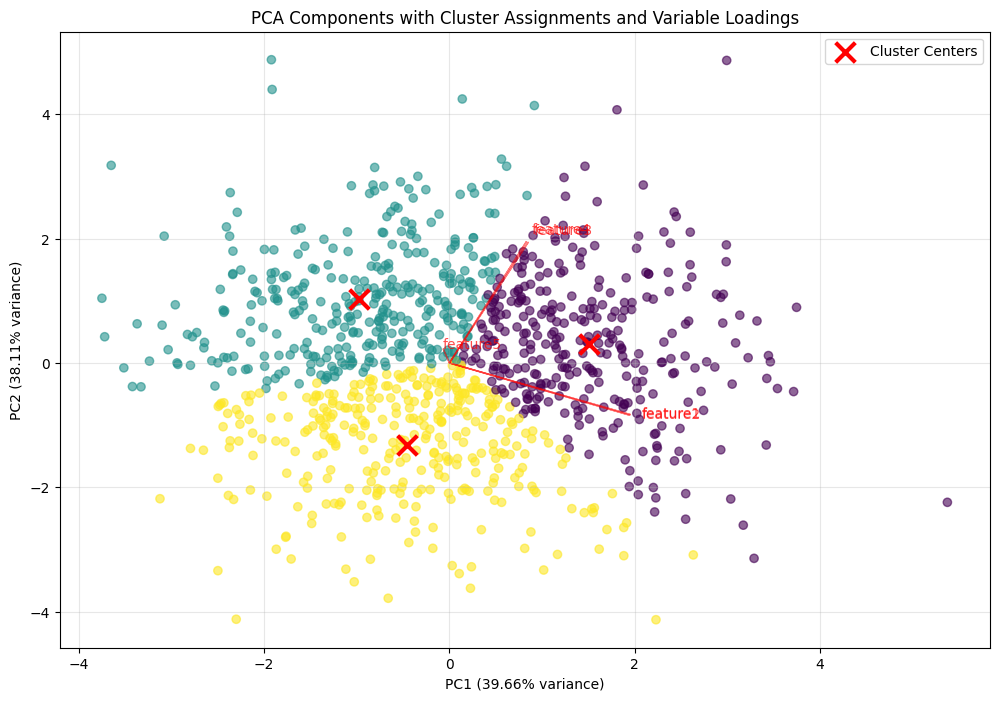

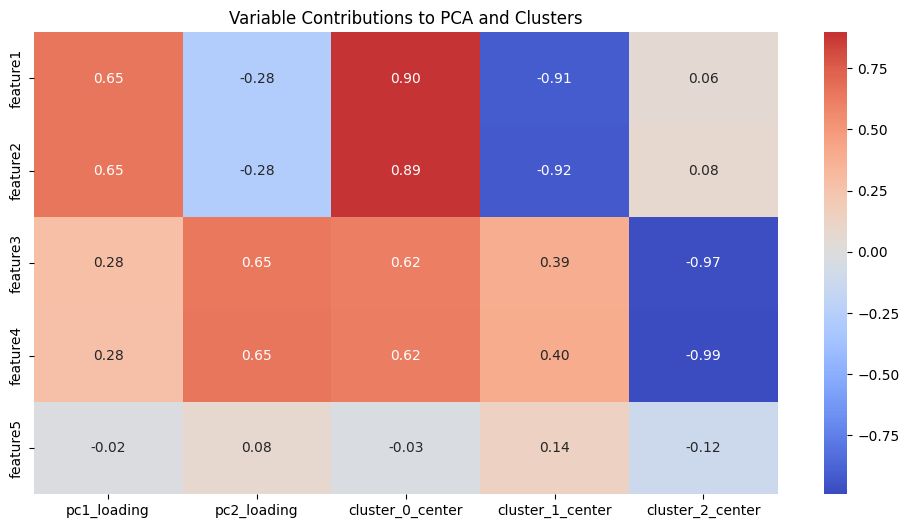

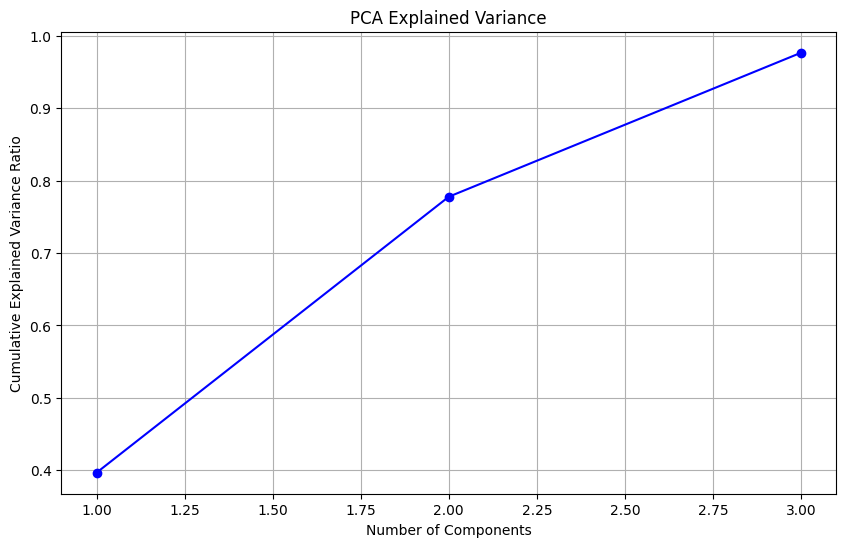

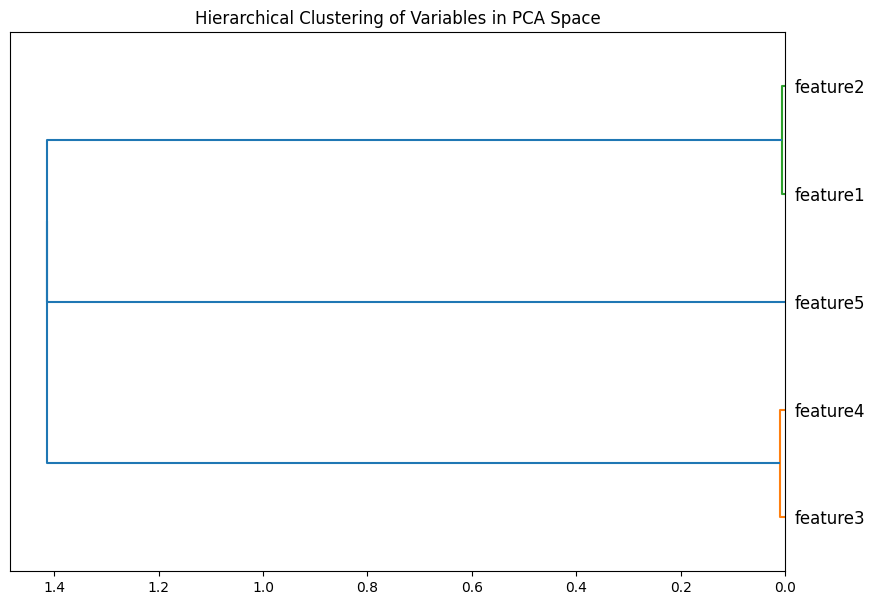

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

class PCAClusterAnalyzer:
    def __init__(self, data, n_components=None, n_clusters=3):
        self.data = data
        self.n_components = n_components or len(data.columns)
        self.n_clusters = n_clusters
        self.scaler = StandardScaler()
        
    def analyze_relationships(self):
        """
        Analyze relationships between PCA and clustering
        """
        # Scale the data
        X_scaled = self.scaler.fit_transform(self.data)
        
        # Perform PCA
        pca_results = self._perform_pca(X_scaled)
        
        # Perform clustering
        cluster_results = self._perform_clustering(X_scaled)
        
        # Analyze relationships
        relationships = self._analyze_pca_cluster_relationship(
            pca_results, 
            cluster_results
        )
        
        return {
            'pca': pca_results,
            'clustering': cluster_results,
            'relationships': relationships
        }
    
    def _perform_pca(self, X_scaled):
        """
        Perform PCA analysis
        """
        pca = PCA(n_components=self.n_components)
        components = pca.fit_transform(X_scaled)
        
        # Calculate loadings
        loadings = pd.DataFrame(
            pca.components_.T,
            columns=[f'PC{i+1}' for i in range(self.n_components)],
            index=self.data.columns
        )
        
        # Explained variance
        explained_variance = pca.explained_variance_ratio_
        
        return {
            'components': components,
            'loadings': loadings,
            'explained_variance': explained_variance,
            'pca_obj': pca
        }
    
    def _perform_clustering(self, X_scaled):
        """
        Perform clustering analysis
        """
        kmeans = KMeans(n_clusters=self.n_clusters, random_state=42)
        clusters = kmeans.fit_predict(X_scaled)
        
        # Project cluster centers
        centers = pd.DataFrame(
            kmeans.cluster_centers_,
            columns=self.data.columns
        )
        
        return {
            'clusters': clusters,
            'centers': centers,
            'kmeans_obj': kmeans
        }
    
    def _analyze_pca_cluster_relationship(self, pca_results, cluster_results):
        """
        Analyze relationship between PCA and clustering results
        """
        # Project cluster centers onto PCA space
        center_projection = pca_results['pca_obj'].transform(
            cluster_results['centers']
        )
        
        # Analyze variable contributions to both PCA and clusters
        variable_analysis = pd.DataFrame(index=self.data.columns)
        
        # PCA contributions
        variable_analysis['pc1_loading'] = pca_results['loadings']['PC1']
        variable_analysis['pc2_loading'] = pca_results['loadings']['PC2']
        
        # Cluster contributions
        for i in range(self.n_clusters):
            variable_analysis[f'cluster_{i}_center'] = cluster_results['centers'].iloc[i]
        
        return {
            'center_projection': center_projection,
            'variable_analysis': variable_analysis
        }
    
    def visualize_relationships(self, results):
        """
        Create visualizations showing PCA and clustering relationships
        """
        # 1. PCA vs Clustering Scatter Plot
        plt.figure(figsize=(12, 8))
        
        # Plot points
        scatter = plt.scatter(
            results['pca']['components'][:, 0],
            results['pca']['components'][:, 1],
            c=results['clustering']['clusters'],
            cmap='viridis',
            alpha=0.6
        )
        
        # Plot cluster centers projection
        center_proj = results['relationships']['center_projection']
        plt.scatter(
            center_proj[:, 0],
            center_proj[:, 1],
            c='red',
            marker='x',
            s=200,
            linewidths=3,
            label='Cluster Centers'
        )
        
        # Plot variable loadings
        loadings = results['pca']['loadings']
        for i, variable in enumerate(self.data.columns):
            plt.arrow(
                0, 0,
                loadings.iloc[i, 0] * 3,
                loadings.iloc[i, 1] * 3,
                color='r',
                alpha=0.5
            )
            plt.text(
                loadings.iloc[i, 0] * 3.2,
                loadings.iloc[i, 1] * 3.2,
                variable,
                color='r',
                alpha=0.7
            )
        
        plt.xlabel(f"PC1 ({results['pca']['explained_variance'][0]:.2%} variance)")
        plt.ylabel(f"PC2 ({results['pca']['explained_variance'][1]:.2%} variance)")
        plt.title('PCA Components with Cluster Assignments and Variable Loadings')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # 2. Variable Contributions Heatmap
        var_analysis = results['relationships']['variable_analysis']
        plt.figure(figsize=(12, 6))
        sns.heatmap(
            var_analysis,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt='.2f'
        )
        plt.title('Variable Contributions to PCA and Clusters')
        plt.show()
        
        # 3. Explained Variance Plot
        plt.figure(figsize=(10, 6))
        plt.plot(
            range(1, len(results['pca']['explained_variance']) + 1),
            np.cumsum(results['pca']['explained_variance']),
            'bo-'
        )
        plt.xlabel('Number of Components')
        plt.ylabel('Cumulative Explained Variance Ratio')
        plt.title('PCA Explained Variance')
        plt.grid(True)
        plt.show()

# Generate example data with clear structure
def generate_structured_data(n_samples=1000):
    np.random.seed(42)
    
    # Create correlated features
    x1 = np.random.normal(0, 1, n_samples)
    x2 = 0.8 * x1 + 0.2 * np.random.normal(0, 1, n_samples)
    x3 = np.random.normal(0, 1, n_samples)
    x4 = 0.7 * x3 + 0.3 * np.random.normal(0, 1, n_samples)
    x5 = np.random.normal(0, 1, n_samples)
    
    data = pd.DataFrame({
        'feature1': x1,
        'feature2': x2,
        'feature3': x3,
        'feature4': x4,
        'feature5': x5
    })
    
    return data

# Run analysis
data = generate_structured_data()
analyzer = PCAClusterAnalyzer(data, n_components=3, n_clusters=3)
results = analyzer.analyze_relationships()

# Print insights
print("\nPCA and Clustering Relationship Analysis")
print("=====================================")

print("\n1. PCA Insights:")
print("Explained Variance Ratio by Component:")
for i, var in enumerate(results['pca']['explained_variance'], 1):
    print(f"PC{i}: {var:.3f} ({var:.1%})")

print("\n2. Variable Loadings (top 2 PCs):")
loadings = results['pca']['loadings']
for variable in data.columns:
    print(f"\n{variable}:")
    print(f"  PC1: {loadings.loc[variable, 'PC1']:.3f}")
    print(f"  PC2: {loadings.loc[variable, 'PC2']:.3f}")

print("\n3. Cluster Characteristics:")
centers = results['clustering']['centers']
for i in range(len(centers)):
    print(f"\nCluster {i}:")
    for col in centers.columns:
        print(f"  {col}: {centers.iloc[i][col]:.3f}")

# Visualize relationships
analyzer.visualize_relationships(results)

# Additional analysis: Variable clustering in PCA space
def analyze_variable_clusters_in_pca(results):
    """
    Analyze how variables cluster in PCA space
    """
    loadings = results['pca']['loadings']
    
    # Perform hierarchical clustering on loadings
    linkage_matrix = linkage(loadings, method='ward')
    
    plt.figure(figsize=(10, 7))
    dendrogram(
        linkage_matrix,
        labels=loadings.index,
        orientation='left'
    )
    plt.title('Hierarchical Clustering of Variables in PCA Space')
    plt.show()

analyze_variable_clusters_in_pca(results)


Multicollinearity Analysis using PCA

1. Condition Number Analysis:
Condition Number: 17.75
CAUTION: Moderate multicollinearity present

2. Variance Explained by Principal Components:

PC1:
  Eigenvalue: 2.009
  Variance Explained: 40.1%
  Cumulative Variance: 40.1%

PC2:
  Eigenvalue: 1.908
  Variance Explained: 38.1%
  Cumulative Variance: 78.3%

PC3:
  Eigenvalue: 0.996
  Variance Explained: 19.9%
  Cumulative Variance: 98.2%

PC4:
  Eigenvalue: 0.086
  Variance Explained: 1.7%
  Cumulative Variance: 99.9%

PC5:
  Eigenvalue: 0.006
  Variance Explained: 0.1%
  Cumulative Variance: 100.0%

3. Collinear Groups Detected:


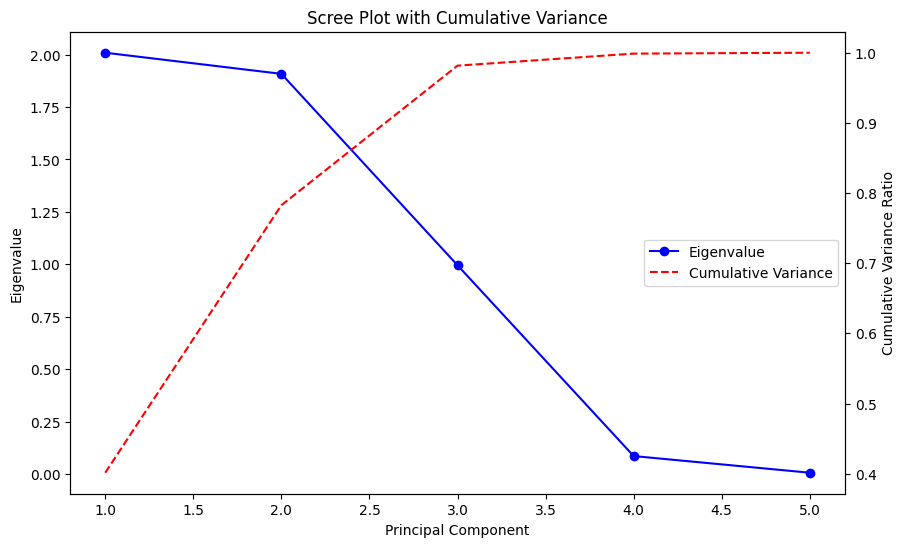

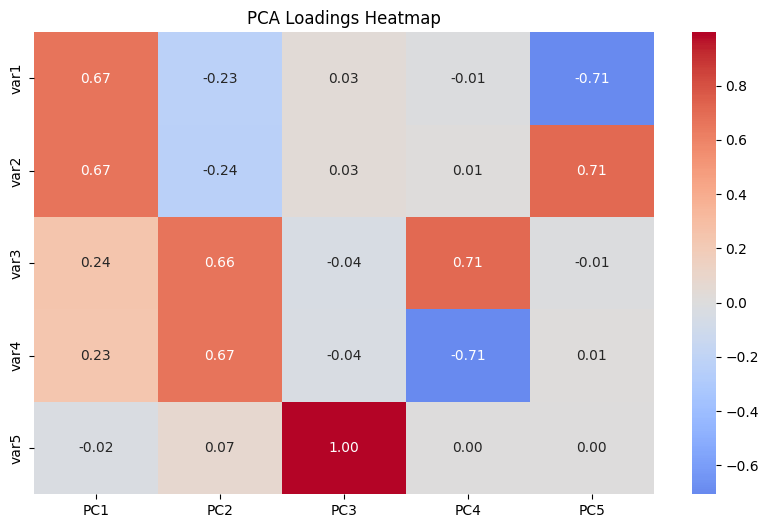

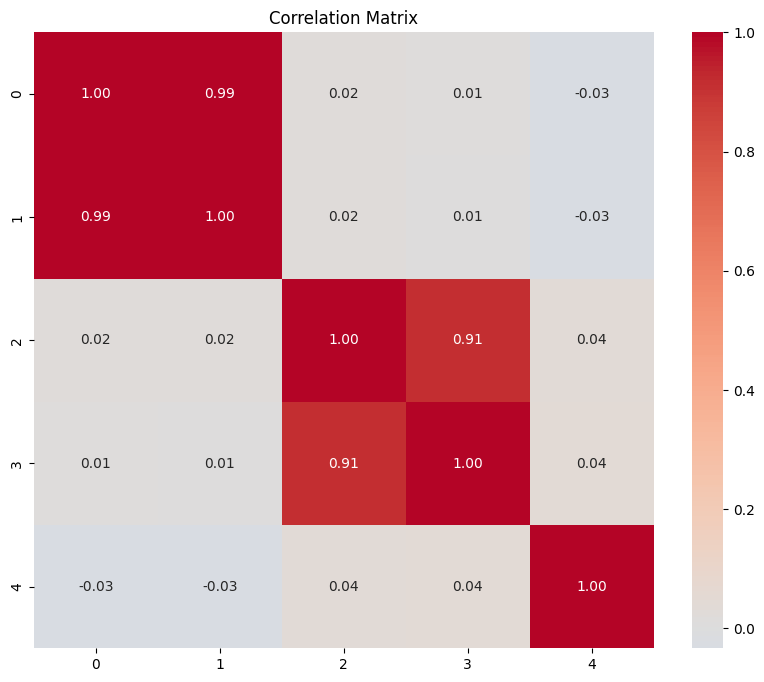

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

class MulticollinearityDetector:
    def __init__(self, data):
        self.data = data
        self.scaler = StandardScaler()
        
    def analyze_multicollinearity(self):
        """
        Comprehensive multicollinearity analysis using PCA
        """
        # Scale the data
        X_scaled = self.scaler.fit_transform(self.data)
        
        # Perform PCA
        pca_results = self._perform_pca(X_scaled)
        
        # Analyze condition number
        condition_analysis = self._analyze_condition_number(X_scaled)
        
        # Analyze variable relationships
        relationship_analysis = self._analyze_variable_relationships(
            pca_results, condition_analysis
        )
        
        return {
            'pca_results': pca_results,
            'condition_analysis': condition_analysis,
            'relationships': relationship_analysis
        }
    
    def _perform_pca(self, X_scaled):
        """
        Perform PCA and extract key metrics
        """
        pca = PCA()
        components = pca.fit_transform(X_scaled)
        
        # Calculate loadings
        loadings = pd.DataFrame(
            pca.components_.T,
            columns=[f'PC{i+1}' for i in range(len(self.data.columns))],
            index=self.data.columns
        )
        
        # Variance explained
        explained_variance = pd.DataFrame({
            'eigenvalue': pca.explained_variance_,
            'variance_ratio': pca.explained_variance_ratio_,
            'cumulative_variance_ratio': np.cumsum(pca.explained_variance_ratio_)
        })
        
        return {
            'components': components,
            'loadings': loadings,
            'explained_variance': explained_variance,
            'pca_obj': pca
        }
    
    def _analyze_condition_number(self, X_scaled):
        """
        Analyze condition number and its implications
        """
        # Calculate correlation matrix
        corr_matrix = np.corrcoef(X_scaled.T)
        
        # Calculate eigenvalues of correlation matrix
        eigenvalues = np.linalg.eigvals(corr_matrix)
        
        # Calculate condition number
        condition_number = np.sqrt(max(eigenvalues) / min(eigenvalues))
        
        return {
            'condition_number': condition_number,
            'eigenvalues': eigenvalues,
            'correlation_matrix': corr_matrix
        }
    
    def _analyze_variable_relationships(self, pca_results, condition_analysis):
        """
        Analyze relationships between variables using PCA results
        """
        # Identify highly correlated variables using loadings
        loadings = pca_results['loadings']
        
        # Calculate variable importance in each PC
        var_importance = pd.DataFrame(
            np.square(loadings),
            columns=loadings.columns,
            index=loadings.index
        )
        
        # Identify potential collinear groups
        collinear_groups = self._identify_collinear_groups(
            loadings, var_importance
        )
        
        return {
            'variable_importance': var_importance,
            'collinear_groups': collinear_groups
        }
    
    def _identify_collinear_groups(self, loadings, var_importance, threshold=0.7):
        """
        Identify groups of potentially collinear variables
        """
        groups = []
        
        # Look at loadings in first few PCs
        for pc in loadings.columns[:2]:  # Focus on first two PCs
            # Get variables with high loadings
            high_loading_vars = loadings[abs(loadings[pc]) > threshold].index
            if len(high_loading_vars) > 1:
                groups.append(list(high_loading_vars))
        
        return groups
    
    def visualize_analysis(self, results):
        """
        Create visualizations for multicollinearity analysis
        """
        # 1. Scree plot with cumulative variance
        exp_var = results['pca_results']['explained_variance']
        
        fig, ax1 = plt.subplots(figsize=(10, 6))
        ax2 = ax1.twinx()
        
        # Plot eigenvalues
        ax1.plot(range(1, len(exp_var) + 1), 
                exp_var['eigenvalue'], 
                'bo-', label='Eigenvalue')
        ax1.set_xlabel('Principal Component')
        ax1.set_ylabel('Eigenvalue')
        
        # Plot cumulative variance
        ax2.plot(range(1, len(exp_var) + 1), 
                exp_var['cumulative_variance_ratio'], 
                'r--', label='Cumulative Variance')
        ax2.set_ylabel('Cumulative Variance Ratio')
        
        plt.title('Scree Plot with Cumulative Variance')
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
        plt.show()
        
        # 2. Loading plot
        loadings = results['pca_results']['loadings']
        plt.figure(figsize=(10, 6))
        sns.heatmap(loadings, 
                   cmap='coolwarm', 
                   center=0,
                   annot=True,
                   fmt='.2f')
        plt.title('PCA Loadings Heatmap')
        plt.show()
        
        # 3. Correlation matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(results['condition_analysis']['correlation_matrix'],
                   cmap='coolwarm',
                   center=0,
                   annot=True,
                   fmt='.2f')
        plt.title('Correlation Matrix')
        plt.show()

# Generate example data with multicollinearity
def generate_multicollinear_data(n_samples=1000):
    np.random.seed(42)
    
    # Create correlated variables
    x1 = np.random.normal(0, 1, n_samples)
    x2 = 0.9 * x1 + 0.1 * np.random.normal(0, 1, n_samples)  # Strong correlation with x1
    x3 = np.random.normal(0, 1, n_samples)
    x4 = 0.7 * x3 + 0.3 * np.random.normal(0, 1, n_samples)  # Moderate correlation with x3
    x5 = np.random.normal(0, 1, n_samples)  # Independent variable
    
    data = pd.DataFrame({
        'var1': x1,
        'var2': x2,
        'var3': x3,
        'var4': x4,
        'var5': x5
    })
    
    return data

# Run analysis
data = generate_multicollinear_data()
detector = MulticollinearityDetector(data)
results = detector.analyze_multicollinearity()

# Print insights
print("\nMulticollinearity Analysis using PCA")
print("==================================")

print("\n1. Condition Number Analysis:")
condition_number = results['condition_analysis']['condition_number']
print(f"Condition Number: {condition_number:.2f}")
if condition_number > 30:
    print("WARNING: High multicollinearity detected")
elif condition_number > 15:
    print("CAUTION: Moderate multicollinearity present")
else:
    print("Multicollinearity appears to be within acceptable limits")

print("\n2. Variance Explained by Principal Components:")
exp_var = results['pca_results']['explained_variance']
for i, (eigen, var_ratio, cum_ratio) in exp_var.iterrows():
    print(f"\nPC{i+1}:")
    print(f"  Eigenvalue: {eigen:.3f}")
    print(f"  Variance Explained: {var_ratio:.1%}")
    print(f"  Cumulative Variance: {cum_ratio:.1%}")

print("\n3. Collinear Groups Detected:")
for i, group in enumerate(results['relationships']['collinear_groups'], 1):
    print(f"\nGroup {i}:")
    print(f"  Variables: {', '.join(group)}")

# Visualize results
detector.visualize_analysis(results)